In [1]:
# 이 셀은 실행 환경과 corpus 경로를 준비합니다.
# Colab 모두 실행용 셋업 셀
# 이 셀은 런타임 → 모두 실행을 눌렀을 때 필요한 파일/폴더/패키지를 자동으로 준비합니다.

import os
import sys
import subprocess
import zipfile
import urllib.request
from pathlib import Path

# 기본값은 Colab에서 끊기지 않고 끝까지 도는 빠른 실행 모드입니다.
# 그래프가 선으로 보이도록 epoch 기본값은 3으로 설정했습니다.
# 전체 데이터로 오래 학습하려면 아래 값을 "0"으로 바꾸면 됩니다.
os.environ.setdefault("BERT_PRETRAIN_FAST_RUN", "0")
os.environ.setdefault("BERT_PRETRAIN_MAX_LINES", "20000")
os.environ.setdefault("BERT_PRETRAIN_COUNT", "4096")
os.environ.setdefault("BERT_PRETRAIN_EPOCHS", "10")
os.environ.setdefault("BERT_PRETRAIN_BATCH_SIZE", "64")
os.environ.setdefault("BERT_PRETRAIN_SP_VOCAB_SIZE", "8000")
os.environ.setdefault("BERT_PRETRAIN_MODEL_PREFIX", "ko_8000")

# 패키지 설치 - 설치된경우 주석처리
# subprocess.check_call([
#     sys.executable, "-m", "pip", "install", "-q",
#     "sentencepiece", "tqdm", "torchinfo"
# ])

BASE_DIR = Path("/content") if Path("/content").exists() else Path.cwd()
os.chdir(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "models"
WORK_DIR = BASE_DIR / "work"
for path in (DATA_DIR, MODEL_DIR, WORK_DIR):
    path.mkdir(parents=True, exist_ok=True)

CORPUS_URL = "https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip"
zip_path = DATA_DIR / "kowiki.txt.zip"
corpus_path = DATA_DIR / "kowiki.txt"

# corpus 다운로드 및 압축 해제
if not corpus_path.exists():
    try:
        if not zip_path.exists():
            print("Downloading kowiki.txt.zip...")
            urllib.request.urlretrieve(CORPUS_URL, zip_path)

        print("Extracting kowiki.txt.zip...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(DATA_DIR)

        found = list(DATA_DIR.rglob("kowiki.txt"))
        if found:
            found_path = found[0]
            if found_path != corpus_path:
                corpus_path.write_text(found_path.read_text(encoding="utf-8"), encoding="utf-8")
    except Exception as e:
        print("kowiki.txt 다운로드에 실패해 샘플 corpus로 대체합니다.")
        print("실제 학습을 하려면 data/kowiki.txt를 직접 업로드하세요.")
        sample_text = """
인공지능은 컴퓨터가 사람처럼 학습하고 추론하도록 만드는 기술이다.
자연어 처리는 사람이 사용하는 언어를 컴퓨터가 이해하도록 만드는 분야이다.
BERT는 Transformer encoder 구조를 기반으로 만들어진 언어 모델이다.
Masked Language Modeling은 일부 토큰을 가리고 원래 토큰을 맞히는 학습 방식이다.
Next Sentence Prediction은 두 문장이 이어지는지 판단하는 학습 방식이다.

딥러닝 모델은 많은 데이터를 사용하여 패턴을 학습한다.
토크나이저는 문장을 작은 단위의 토큰으로 나누는 역할을 한다.
SentencePiece는 subword 기반 토크나이저를 만들 때 자주 사용된다.
""".strip()
        corpus_path.write_text((sample_text + "\n\n") * 2000, encoding="utf-8")

# 빠른 실행 모드에서는 corpus 일부만 사용합니다.
fast_run = os.environ.get("BERT_PRETRAIN_FAST_RUN", "1") == "1"
if fast_run:
    max_lines = int(os.environ.get("BERT_PRETRAIN_MAX_LINES", "20000"))
    run_corpus_path = DATA_DIR / "kowiki_colab_small.txt"
    if not run_corpus_path.exists():
        print(f"Creating small corpus for fast run: first {max_lines} lines")
        with open(corpus_path, "r", encoding="utf-8") as in_f, open(run_corpus_path, "w", encoding="utf-8") as out_f:
            for i, line in enumerate(in_f):
                if i >= max_lines:
                    break
                out_f.write(line)
else:
    run_corpus_path = corpus_path

os.environ["BERT_PRETRAIN_CORPUS_FILE"] = str(run_corpus_path)

# SentencePiece 모델이 없으면 자동 생성합니다.
# 빠른 실행을 위해 기본 vocab size는 8000으로 둡니다.
import sentencepiece as spm
model_path = DATA_DIR / "ko_8000.model"
if not model_path.exists() and not (MODEL_DIR / "ko_8000.model").exists():
    sp_vocab_size = int(os.environ.get("BERT_PRETRAIN_SP_VOCAB_SIZE", "8000"))
    prefix = DATA_DIR / "ko_8000"
    print(f"Training SentencePiece model. vocab_size={sp_vocab_size}")
    spm.SentencePieceTrainer.train(
        f"--input={run_corpus_path} "
        f"--model_prefix={prefix} "
        f"--vocab_size={sp_vocab_size} "
        "--model_type=bpe "
        "--max_sentence_length=999999 "
        "--pad_id=0 --pad_piece=[PAD] "
        "--unk_id=1 --unk_piece=[UNK] "
        "--bos_id=2 --bos_piece=[BOS] "
        "--eos_id=3 --eos_piece=[EOS] "
        "--user_defined_symbols=[SEP],[CLS],[MASK] "
        "--hard_vocab_limit=false"
    )

print("Colab setup finished.")
print("corpus_file:", os.environ["BERT_PRETRAIN_CORPUS_FILE"])
print("fast_run:", fast_run)
print("train_count:", os.environ["BERT_PRETRAIN_COUNT"])
print("epochs:", os.environ["BERT_PRETRAIN_EPOCHS"])
print("batch_size:", os.environ["BERT_PRETRAIN_BATCH_SIZE"])


Colab setup finished.
corpus_file: f:\code\AIFFEL\AIFFEL_study\BERT_pretrained\data\kowiki.txt
fast_run: False
train_count: 4096
epochs: 10
batch_size: 64


---
프로젝트 노트북의 도입부 구분 셀입니다.


# Mini BERT Pretraining Project


이 노트북은 샘플 `bert_colab.ipynb`의 셀 흐름을 유지하면서 vocab size 8000, 약 1M 파라미터 규모의 mini BERT pretraining 프로젝트에 맞게 정리한 버전입니다.


이번 프로젝트에서는 한글 위키 corpus로 SentencePiece tokenizer를 만들고, BERT의 두 가지 pretrain task인 MLM과 NSP 데이터를 구성합니다.

- SentencePiece vocab size는 특수 토큰을 포함해 8000으로 맞춥니다.
- MLM은 전체 토큰의 약 15%를 대상으로 하며 80% `[MASK]`, 10% 랜덤 토큰, 10% 원래 토큰 규칙을 사용합니다.
- NSP는 두 segment를 묶어 50% 확률로 `is_next=True/False` label을 만듭니다.
- JSONL dataset을 저장한 뒤 `np.memmap`으로 로딩해 메모리 사용량을 줄입니다.
- mini BERT를 10 epoch까지 학습하고 NSP/MLM loss와 accuracy를 시각화합니다.


---
데이터 준비 안내로 넘어가는 구분 셀입니다.


## 데이터 다운로드
---
[kowiki.txt.zip](https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip)

```
$ mkdir -p ~/work/bert_pretrain/data
$ mkdir -p ~/work/bert_pretrain/models
$ wget https://aiffelstaticprd.blob.core.windows.net/media/documents/kowiki.txt.zip
$ mv kowiki.txt.zip ~/work/bert_pretrain/data
$ cd ~/work/bert_pretrain/data && unzip kowiki.txt.zip
```

혹시 이번 실습에서 필요한 아래 라이브러리가 없다면 미리 설치해 주세요.


```
$ pip install sentencepiece
$ pip install tqdm
$ conda install -c conda-forge ipywidgets
$ jupyter nbextension enable --py widgetsnbextension
```


In [2]:
# 이 셀은 로컬 폴더 생성 참고 명령을 제공합니다.
#로컬에서 진행하실 경우 다음과 같이 경로설정을 합니다
#!mkdir data
#!mkdir models


In [3]:
# 이 셀은 corpus 다운로드 참고 명령을 제공합니다.
#LMS에는 데이터가 준비되어 있습니다
#!wget https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip


In [4]:
# 이 셀은 corpus 이동 참고 명령을 제공합니다.
#LMS에는 데이터가 준비되어 있습니다
#!mv kowiki.txt.zip /content/data


In [5]:
# 이 셀은 corpus 압축 해제 참고 명령을 제공합니다.
#LMS에는 데이터가 압축이 풀린 채로 준비되어 있습니다.
#%cd /content/data
#!unzip kowiki.txt.zip


In [6]:
# 이 셀은 필요한 패키지를 설치합니다.
# 다음 라이브러리를 설치해주세요.
# Jupyter 환경에서는 !pip보다 %pip가 현재 커널에 더 안전하게 설치합니다.
%pip install -q sentencepiece tqdm torchinfo


Note: you may need to restart the kernel to use updated packages.


f:\code\AIFFEL\AIFFEL_study\.venv\Scripts\python.exe: No module named pip


## 학습 내용

- **Tokenizer 준비**: 한글 corpus로 vocab size 8000 SentencePiece 모델을 만듭니다.
- **데이터 전처리**: MLM mask와 NSP pair를 함수로 먼저 만들고 바로 적용합니다.
- **데이터셋 완성**: JSONL로 저장한 뒤 `np.memmap`으로 메모리 사용량을 줄여 로딩합니다.
- **BERT 모델 구현**: Embedding, Transformer encoder, pretrain head를 PyTorch로 구현합니다.
- **pretrain 진행**: mini BERT를 10 epoch까지 학습하고 손실/정확도를 시각화합니다.


## 학습 목표

- BERT pretrain 데이터가 MLM과 NSP를 동시에 담도록 구성할 수 있습니다.
- 약 1M 파라미터 규모의 mini BERT 구조를 직접 구현할 수 있습니다.
- 학습 과정에서 NSP와 MLM의 loss/accuracy 변화를 해석할 수 있습니다.


---
Tokenizer 준비 섹션으로 넘어가는 구분 셀입니다.


# 1. Tokenizer 준비


BERT등의 pretrained model이 나오게 되었을 즈음 자연어처리 분야의 또 다른 중요한 흐름 중 하나는 BPE 등의 subword 기반의 토크나이징 기법이 주요한 방법론으로 굳어졌다는 점입니다. GPT의 BPE, BERT의 WordPiece 모델 등의 성공이 더욱 사람들에게 subword 기반의 토크나이저에 대한 확신을 주었습니다.

오늘 우리는 [SentencePiece](https://github.com/google/sentencepiece) 기반의 토크나이저를 준비하는 것으로 BERT pretrain 과정을 시작할 것입니다. 이 과정 자체는 이미 익숙하실 것이라 생각합니다.


In [7]:
# 이 셀은 라이브러리를 불러오고 난수를 고정합니다.
# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import os
import re
import math
import random
import collections
import json
import shutil
import zipfile
import copy
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import sentencepiece as spm
from tqdm.auto import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

# torch version
print(torch.__version__)


2.10.0+cu128


준비해 둔 한글 나무위키 corpus로부터 vocab size 8000의 SentencePiece 모델을 생성합니다.

첫 번째 셀의 빠른 실행 옵션이 켜져 있으면 작은 corpus 조각으로 tokenizer를 만들 수 있습니다. 실제 제출 실험에서는 `BERT_PRETRAIN_FAST_RUN=0` 또는 더 큰 `BERT_PRETRAIN_MAX_LINES`를 사용하면 됩니다.


`data/ko_8000.model`과 `data/ko_8000.vocab`이 생성되면 tokenizer 준비가 완료된 것입니다.


> SentencePiece의 `vocab_size=8000`은 `[PAD]`, `[UNK]`, `[BOS]`, `[EOS]`, `[SEP]`, `[CLS]`, `[MASK]`를 포함한 전체 vocab 크기입니다.


In [8]:
# 이 셀은 8000 vocab SentencePiece 모델을 학습하거나 기존 모델을 확인합니다.
import sentencepiece as spm
from pathlib import Path

data_dir = Path("data")
model_dir = Path("models")
corpus_file = Path(os.environ.get("BERT_PRETRAIN_CORPUS_FILE", str(data_dir / "kowiki.txt")))
model_prefix = os.environ.get("BERT_PRETRAIN_MODEL_PREFIX", "ko_8000")
vocab_size = int(os.environ.get("BERT_PRETRAIN_SP_VOCAB_SIZE", "8000"))
prefix = data_dir / model_prefix

candidate_model_paths = [
    data_dir / f"{model_prefix}.model",
    model_dir / f"{model_prefix}.model",
]
model_path = next((path for path in candidate_model_paths if path.exists()), None)

if model_path is None:
    print(f"Training SentencePiece model: {prefix}.model, vocab_size={vocab_size}")
    spm.SentencePieceTrainer.train(
        f"--input={corpus_file} "
        f"--model_prefix={prefix} "
        f"--vocab_size={vocab_size} "
        "--model_type=bpe "
        "--max_sentence_length=999999 "
        "--pad_id=0 --pad_piece=[PAD] "
        "--unk_id=1 --unk_piece=[UNK] "
        "--bos_id=2 --bos_piece=[BOS] "
        "--eos_id=3 --eos_piece=[EOS] "
        "--user_defined_symbols=[SEP],[CLS],[MASK] "
        "--hard_vocab_limit=false"
    )
    model_path = data_dir / f"{model_prefix}.model"
else:
    print("Using existing SentencePiece model:", model_path)


Using existing SentencePiece model: data\ko_8000.model


In [9]:
# 이 셀은 SentencePiece 모델을 로드하고 실제 vocab 크기와 특수 토큰 id를 확인합니다.
candidate_model_paths = [
    data_dir / f"{model_prefix}.model",
    model_dir / f"{model_prefix}.model",
]
model_path = next((path for path in candidate_model_paths if path.exists()), None)

if model_path is None:
    raise FileNotFoundError(
        f"{model_prefix}.model을 찾을 수 없습니다. 바로 위 SentencePiece 학습 셀을 먼저 실행하세요."
    )

vocab = spm.SentencePieceProcessor()
vocab.load(str(model_path))
REAL_VOCAB_SIZE = vocab.get_piece_size()
print("Loaded SentencePiece model:", model_path)
print("REAL_VOCAB_SIZE:", REAL_VOCAB_SIZE)
print("special ids:", {piece: vocab.piece_to_id(piece) for piece in ["[PAD]", "[UNK]", "[BOS]", "[EOS]", "[SEP]", "[CLS]", "[MASK]"]})


Loaded SentencePiece model: data\ko_8000.model
REAL_VOCAB_SIZE: 8000
special ids: {'[PAD]': 0, '[UNK]': 1, '[BOS]': 2, '[EOS]': 3, '[SEP]': 4, '[CLS]': 5, '[MASK]': 6}


토크나이저가 잘 만들어졌는지 확인해 봅시다. 어떤 토큰이 만들어졌는지, 토크나이징 결과가 어떻게 나오는지 살펴볼까요?


In [10]:
# 이 셀은 일반 vocab 후보를 만듭니다.
# Q. 특수 token 7개를 제외한 나머지 token들을 출력해봅시다.
vocab_list = []
for token_id in range(7, vocab.get_piece_size()):
    if not vocab.is_unknown(token_id):
        vocab_list.append(vocab.id_to_piece(token_id))

print("vocab_list size:", len(vocab_list))
print(vocab_list[:100])


vocab_list size: 7993
['▁이', '▁1', '으로', '▁있', '에서', '▁그', '▁대', '▁사', '▁수', '▁2', '었다', '▁기', '▁가', '▁한', '▁전', '▁정', '▁지', '▁있다', '하는', '▁19', '하였', '▁아', '▁다', '▁시', '했다', '▁것', '▁중', '▁일', '이다', '▁자', '▁제', '▁유', '▁공', '▁인', '▁주', '▁하', '▁등', '하였다', '▁경', '▁위', '하고', '하여', '00', '▁의', '▁국', '되었다', '▁보', '한다', '▁나', '▁연', '▁발', '▁비', '에는', '▁조', '▁소', '▁모', '▁개', '▁부', '▁영', '으며', '▁미', '▁때', '▁3', '▁동', '▁세', '▁관', '▁해', '▁구', '적인', '▁오', '▁여', '▁고', '▁상', '▁문', '▁서', '▁같', '▁않', 'or', '▁도', '▁대한', '적으로', '▁만', '▁방', '▁선', '▁"', '▁사용', '▁통', '▁또', '▁생', '▁프', 'la', '이라', '▁마', '▁내', '▁따', '▁성', '▁후', '▁실', '▁스', '▁신']


In [11]:
# 이 셀은 BERT 입력 토큰 예시를 만듭니다.
# [CLS], tokens a, [SEP], tokens b, [SEP] 형태의 token 생성
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"
tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
print(tokens_org)


['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']


In [12]:
# 이 셀은 예시 입력 길이를 확인합니다.
print(len(tokens_org))


93


In [13]:
# 이 셀은 vocab 전체를 한 번에 출력하지 않고 앞/뒤 일부만 확인합니다.
print("first 50:", vocab_list[:50])
print("last 50:", vocab_list[-50:])


first 50: ['▁이', '▁1', '으로', '▁있', '에서', '▁그', '▁대', '▁사', '▁수', '▁2', '었다', '▁기', '▁가', '▁한', '▁전', '▁정', '▁지', '▁있다', '하는', '▁19', '하였', '▁아', '▁다', '▁시', '했다', '▁것', '▁중', '▁일', '이다', '▁자', '▁제', '▁유', '▁공', '▁인', '▁주', '▁하', '▁등', '하였다', '▁경', '▁위', '하고', '하여', '00', '▁의', '▁국', '되었다', '▁보', '한다', '▁나', '▁연']
last 50: ['帥', '帶', '帽', '幹', '庚', '庫', '廢', '弦', '張', '弼', '彩', '彰', '徒', '從', '御', '復', '循', '恭', '息', '悲', '惟', '愚', '愼', '態', '慧', '戱', '抵', '拜', '指', '振', '掃', '接', '損', '撰', '擬', '擴', '收', '改', '故', '敏', '救', '昭', '晩', '暗', '最', '未', '朱', '杜', '架', '案']


토크나이저가 잘 작동하나요? 방금 우리는 SentencePiece 모델을 이용해 간단한 BERT의 Masked Language Model 학습용 데이터를 하나 생성해 보았습니다.

다음 절부터 본격적으로 데이터 전처리 과정에 돌입하겠습니다.


---
데이터 전처리 섹션으로 넘어가는 구분 셀입니다.


# 2. 데이터 전처리


BERT의 Masked Language Model(MLM)은 전체 입력 토큰 중 일부를 가리고 원래 토큰을 맞히는 방식으로 학습합니다.

아래에서는 먼저 MLM mask 생성 함수를 정의하고, 예시 토큰에 바로 적용합니다. 샘플 노트북처럼 단계별 실험 코드를 길게 반복하지 않고 함수 중심으로 정리했습니다.


In [14]:
# 이 셀은 MLM mask 생성 함수를 먼저 정의하고 예시 토큰에 바로 적용합니다.
def build_word_candidate_indices(tokens):
    """SentencePiece의 단어 시작 기호(▁)를 기준으로 whole-word mask 후보를 묶습니다."""
    cand_idx = []
    for i, token in enumerate(tokens):
        if token in ("[CLS]", "[SEP]"):
            continue
        # SentencePiece에서 ▁로 시작하지 않는 조각은 앞 token과 같은 어절로 봅니다.
        if cand_idx and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])
    return cand_idx


def create_pretrain_mask(tokens, mask_cnt, vocab_list, rng=None):
    """
    MLM 학습용 mask를 생성합니다.
    선택된 토큰은 80% [MASK], 10% 랜덤 토큰, 10% 원래 토큰으로 둡니다.
    """
    rng = rng or random
    tokens = list(tokens)
    valid_token_indices = [i for i, token in enumerate(tokens) if token not in ("[CLS]", "[SEP]")]
    if not valid_token_indices or mask_cnt <= 0:
        return tokens, [], []

    mask_cnt = min(mask_cnt, len(valid_token_indices))
    cand_idx = build_word_candidate_indices(tokens)
    rng.shuffle(cand_idx)

    mask_lms = []
    covered = set()
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if any(index in covered for index in index_set):
            continue
        # whole-word 후보가 mask 목표 개수를 넘기면 이 후보는 건너뜁니다.
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue

        for index in index_set:
            dice = rng.random()
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = rng.choice(vocab_list)
            else:
                masked_token = tokens[index]

            mask_lms.append({"index": index, "label": tokens[index]})
            covered.add(index)
            tokens[index] = masked_token

    # 너무 긴 whole-word 후보 때문에 하나도 선택되지 않는 경우 token 단위 fallback을 사용합니다.
    if not mask_lms:
        for index in valid_token_indices[:mask_cnt]:
            dice = rng.random()
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = rng.choice(vocab_list)
            else:
                masked_token = tokens[index]
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]
    return tokens, mask_idx, mask_label


print(tokens_org)
mask_cnt = max(1, int(round((len(tokens_org) - 3) * 0.15)))
tokens, mask_idx, mask_label = create_pretrain_mask(tokens_org, mask_cnt, vocab_list, rng=random.Random(random_seed))

print("mask_cnt:", mask_cnt)
print("masked tokens:", tokens)
print("mask_idx:", mask_idx)
print("mask_label:", mask_label)


['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']
mask_cnt: 14
masked tokens: ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '[MASK]', '[MASK]', '[MASK]', '▁삼', '십', '▁전', '▁둘째', '번', '[MASK]', '[MASK]', '▁전', '▁오랜', '만에', '▁받아', '보는', '[MASK]', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '[MASK]', '[MASK]', '의', '▁눈', '물이', '▁흘', '러', '[MASK]', '[MASK]', '[MASK]', '▁목', '에', '▁모', '주', '▁한', '잔', 

15%를 마스킹 한다고 해도 생각해 볼 것이 더 있습니다. Subword 기반으로 토크나이징을 했을 때 `_대, [MASK], 민국`이라고 가운데를 마스킹 했을 경우 해당 `[MASK]`가 '한'일 거라는 건 너무 쉽게 맞출 수 있습니다. '대한민국'이라는 패턴을 아주 자주 보게 될 테니까요.

그래서 Masked LM 태스크를 구성할 땐 **띄어쓰기 단위로 한꺼번에 마스킹**해 주는 것이 좋습니다. 다음과 같이 처리합니다.


In [15]:
# 이 셀은 whole-word mask 후보가 어떤 index 묶음으로 만들어지는지 확인합니다.
cand_idx = build_word_candidate_indices(tokens_org)
for cand in cand_idx[:20]:
    print(cand, [tokens_org[i] for i in cand])
print("candidate_count:", len(cand_idx))


[1, 2, 3, 4] ['▁추', '적', '추', '적']
[5, 6] ['▁비', '가']
[7, 8] ['▁내', '리는']
[9, 10, 11] ['▁날', '이었', '어']
[12, 13, 14] ['▁그', '날', '은']
[15, 16, 17] ['▁', '왠', '지']
[18, 19, 20] ['▁손', '님', '이']
[21] ['▁많아']
[22] ['▁첫']
[23, 24] ['▁번', '에']
[25, 26] ['▁삼', '십']
[27] ['▁전']
[28, 29] ['▁둘째', '번']
[30, 31] ['▁오', '십']
[32] ['▁전']
[33, 34] ['▁오랜', '만에']
[35, 36] ['▁받아', '보는']
[37] ['▁십']
[38, 39, 40] ['▁전', '짜', '리']
[41, 42, 43] ['▁백', '통', '화']
candidate_count: 41


In [16]:
# 이 셀은 mask 후보가 무작위 순서로 섞인 뒤 선택된다는 점을 확인합니다.
preview_cand_idx = copy.deepcopy(cand_idx)
random.Random(random_seed).shuffle(preview_cand_idx)
for cand in preview_cand_idx[:10]:
    print(cand, [tokens_org[i] for i in cand])


[23, 24] ['▁번', '에']
[53, 54, 55] ['▁기', '쁨', '의']
[30, 31] ['▁오', '십']
[60, 61, 62] ['▁컬', '컬', '한']
[37] ['▁십']
[75, 76] ['▁전', '부터']
[48, 49, 50] ['▁손', '바', '닥']
[63, 64] ['▁목', '에']
[28, 29] ['▁둘째', '번']
[87, 88] ['▁먹', '고']


In [17]:
# 이 셀은 실제로 MLM label이 생긴 위치와 원래 토큰을 짝지어 보여줍니다.
for index, label in zip(mask_idx, mask_label):
    print(index, label, "->", tokens[index])


22 ▁첫 -> [MASK]
23 ▁번 -> [MASK]
24 에 -> [MASK]
30 ▁오 -> [MASK]
31 십 -> [MASK]
37 ▁십 -> [MASK]
53 ▁기 -> [MASK]
54 쁨 -> [MASK]
55 의 -> 의
60 ▁컬 -> [MASK]
61 컬 -> [MASK]
62 한 -> [MASK]
75 ▁전 -> [MASK]
76 부터 -> [MASK]


개선된 Masking 로직을 다음과 같이 구현해 보았습니다. 마스킹 된 결과를 이전과 비교해 보시죠.


In [18]:
# 이 셀은 원본과 마스킹 결과를 비교합니다.
# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
tokens = copy.deepcopy(tokens_org)

mask_lms = []  # mask 된 값
for index_set in cand_idx:
    if len(mask_lms) >= mask_cnt:  # 핸재 mask된 개수가 15%를 넘으면 중지
          break
    if len(mask_lms) + len(index_set) > mask_cnt:  # 이번에 mask할 개수를 포함해 15%를 넘으면 skip
          continue
    dice = random.random()  # 0과 1 사이의 확률 값

    for index in index_set:
        masked_token = None
        if dice < 0.8:  # 80% replace with [MASK]
            masked_token = "[MASK]"
        elif dice < 0.9: # 10% keep original
            masked_token = tokens[index]
        else:  # 10% random word
            masked_token = random.choice(vocab_list)
        mask_lms.append({"index": index, "label": tokens[index]})
        tokens[index] = masked_token

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens)


tokens_org
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]'] 

tokens
['[CLS]', '▁여러가지', '▁이때', '▁때', '▁폴', '見', '線', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', 

Masked LM의 라벨 데이터도 아래와 같이 생성하여 정리해 둡니다.


In [19]:
# 이 셀은 MLM label을 확인합니다.
# 순서 정렬 및 mask_idx, mask_label 생성
mask_lms = sorted(mask_lms, key=lambda x: x["index"])
mask_idx = [p["index"] for p in mask_lms]
mask_label = [p["label"] for p in mask_lms]

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)


mask_idx   : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
mask_label : ['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은']


In [20]:
# 이 셀은 후보 단위 마스킹 결과를 확인합니다.
for cand in cand_idx:
    print(cand, [tokens[i] for i in cand])


[1, 2, 3, 4] ['▁여러가지', '▁이때', '▁때', '▁폴']
[5, 6] ['見', '線']
[7, 8] ['[MASK]', '[MASK]']
[9, 10, 11] ['[MASK]', '[MASK]', '[MASK]']
[12, 13, 14] ['[MASK]', '[MASK]', '[MASK]']
[15, 16, 17] ['▁', '왠', '지']
[18, 19, 20] ['▁손', '님', '이']
[21] ['▁많아']
[22] ['▁첫']
[23, 24] ['▁번', '에']
[25, 26] ['▁삼', '십']
[27] ['▁전']
[28, 29] ['▁둘째', '번']
[30, 31] ['▁오', '십']
[32] ['▁전']
[33, 34] ['▁오랜', '만에']
[35, 36] ['▁받아', '보는']
[37] ['▁십']
[38, 39, 40] ['▁전', '짜', '리']
[41, 42, 43] ['▁백', '통', '화']
[44, 45, 46] ['▁서', '푼', '에']
[48, 49, 50] ['▁손', '바', '닥']
[51, 52] ['▁위', '엔']
[53, 54, 55] ['▁기', '쁨', '의']
[56, 57] ['▁눈', '물이']
[58, 59] ['▁흘', '러']
[60, 61, 62] ['▁컬', '컬', '한']
[63, 64] ['▁목', '에']
[65, 66] ['▁모', '주']
[67, 68, 69] ['▁한', '잔', '을']
[70, 71] ['▁적', '셔']
[72] ['▁몇']
[73] ['▁달']
[74] ['▁포']
[75, 76] ['▁전', '부터']
[77, 78, 79, 80] ['▁콜', '록', '거', '리는']
[81] ['▁아내']
[82, 83] ['▁생각', '에']
[84, 85, 86] ['▁그', '토', '록']
[87, 88] ['▁먹', '고']
[89, 90, 91] ['▁싶', '다', '던']


### 🔶 create_pretrain_mask() : Masked LM을 위한 코퍼스 생성 메소드
---
이번 스텝에서 구현할 최종 메소드는 아래와 같습니다.


In [21]:
# 이 셀은 create_pretrain_mask()의 출력 길이와 label 위치가 유효한지 점검합니다.
assert len(tokens) == len(tokens_org)
assert len(mask_idx) == len(mask_label)
assert all(tokens_org[idx] == label for idx, label in zip(mask_idx, mask_label))
print("create_pretrain_mask() check passed")


create_pretrain_mask() check passed


`create_pretrain_mask()` 수행 결과를 다시 한번 확인해 봅시다.


In [22]:
# 이 셀은 create_pretrain_mask()를 다시 호출해 재사용 형태를 확인합니다.
tokens, mask_idx, mask_label = create_pretrain_mask(tokens_org, mask_cnt, vocab_list)

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens, "\n")
print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)


tokens_org
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '[MASK]', '[MASK]', '[MASK]', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '[MASK]', '[MASK]', '[MASK]', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '[MASK]', '[MASK]', '[MASK]', '▁목', '에', '[MASK]', '[MASK]', '▁한', '잔', '을', '▁적

---

## (2) NSP pair 생성


다음은 NSP(Next Sentence Prediction) pair를 만드는 과정입니다.

두 문장을 이어 붙여 50%는 실제 순서(`is_next=1`), 50%는 순서를 바꾼 negative pair(`is_next=0`)로 만듭니다. 샘플 노트북의 간단한 실습 방식처럼 같은 chunk 안에서 순서를 바꾸는 방법을 유지합니다.


In [23]:
# 이 셀은 NSP 예시 문서를 준비합니다.
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던
설렁탕 한 그릇을 이제는 살 수 있어
집으로 돌아가는 길 난 문득 떠올라
아내의 목소리가 거칠어만 가는 희박한 숨소리가
오늘은 왠지 나가지 말라던 내 옆에 있어 달라던
그리도 나가고 싶으면 일찍이라도 들어와 달라던
아내의 간절한 목소리가 들려와
나를 원망하듯 비는 점점 거세져
싸늘히 식어가는 아내가 떠올라 걱정은 더해져
난 몰라 오늘은 운수 좋은 날
난 맨날 이렇게 살 수 있으면 얼마나 좋을까"""


In [24]:
# 이 셀은 예시 문서를 토큰화합니다.
# 줄 단위로 tokenize
doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]
doc[:3]


[['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'],
 ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아'],
 ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전']]

우선 원문에서 이어진 두 문장씩 짝지어 보겠습니다.

이 단계에서 넣어줄 특수 token은 `[CLS]`와 `[SEP]`이고, sequence의 최대 길이는 `n_test_seq - 3`으로 정합니다.


In [25]:
# 이 셀은 NSP sequence 길이를 설정합니다.
# 최대 길이
n_test_seq = 64
# 최소 길이
min_seq = 8
# [CLS], tokens_a, [SEP], tokens_b, [SEP]
max_seq = n_test_seq - 3


In [26]:
# 이 셀은 NSP instance 생성 함수를 먼저 정의하고 예시 문서에 바로 적용합니다.
def trim_tokens(tokens_a, tokens_b, max_seq):
    """tokens_a와 tokens_b의 합이 max_seq 이하가 되도록 긴 쪽을 줄입니다."""
    while len(tokens_a) + len(tokens_b) > max_seq:
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()


def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list, rng=None):
    """문서 하나를 받아 NSP와 MLM label이 함께 들어 있는 pretrain instance 목록을 만듭니다."""
    rng = rng or random
    max_seq = n_seq - 3
    instances = []
    current_chunk = []
    current_length = 0

    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])

        if len(current_chunk) > 1 and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = rng.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])

            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            # 실습 단순화: 50% 확률로 두 segment의 순서를 바꿔 NotNext 예시를 만듭니다.
            if rng.random() < 0.5:
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1

            trim_tokens(tokens_a, tokens_b, max_seq)
            if not tokens_a or not tokens_b:
                current_chunk = []
                current_length = 0
                continue

            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            mask_cnt = max(1, int(round((len(tokens) - 3) * mask_prob)))
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list, rng=rng)

            instances.append({
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label,
            })
            current_chunk = []
            current_length = 0

    return instances


instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list, rng=random.Random(random_seed))
print("instances:", len(instances))
print(instances[0] if instances else "no instance")


instances: 3
{'tokens': ['[CLS]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁대표', '[MASK]', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '[MASK]', '잔', '[MASK]', '▁적', '셔', '[SEP]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '[MASK]', '[MASK]', '[MASK]', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '[MASK]', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [11, 12, 20, 21, 22, 37, 38, 39, 54], 'mask_label': ['▁흘', '러', '▁한', '잔', '을', '▁그', '날', '은', '▁번']}


짝지은 두 문장을 그대로 두면 NSP task의 true label 케이스가 되고, 둘의 순서를 뒤바꾸면 false label 케이스가 되겠죠?

두 문장의 최대 길이를 유지하도록 trim을 적용한 후 50%의 확률로 true/false 케이스를 생성해 보겠습니다.

token A의 길이가 `max_seq`보다 길면 앞에서부터 토큰을 제거하고, token B의 길이가 길면 뒤에서부터 토큰을 제거합니다.


In [27]:
# 이 셀은 trim_tokens()가 긴 pair를 어떻게 줄이는지 간단히 확인합니다.
demo_a = list(doc[0])
demo_b = [piece for line in doc[1:6] for piece in line]
print("before:", len(demo_a), len(demo_b), len(demo_a) + len(demo_b))
trim_tokens(demo_a, demo_b, max_seq=20)
print("after :", len(demo_a), len(demo_b), len(demo_a) + len(demo_b))


before: 11 59 70
after : 10 10 20


In [28]:
# 이 셀은 NSP label이 True/False로 만들어졌는지 예시 분포를 확인합니다.
label_counter = collections.Counter(instance["is_next"] for instance in instances)
print("NSP label count:", label_counter)
for instance in instances[:3]:
    print("is_next:", instance["is_next"], "token_len:", len(instance["tokens"]))


NSP label count: Counter({0: 3})
is_next: 0 token_len: 64
is_next: 0 token_len: 64
is_next: 0 token_len: 64


이제 두 문장 사이에 segment 처리를 해주어야 합니다. 첫 번째 문장의 segment는 모두 0으로, 두 번째 문장은 1로 채워준 후 둘 사이에 구분자인 `[SEP]` 등을 넣어주는 것으로 마무리됩니다.

이전 스텝의 `create_pretrain_mask()`까지 함께 호출되어 Mask LM용 데이터셋과 NSP용 데이터셋이 결합된 하나의 데이터셋으로 완성될 것입니다. BERT의 pretrain은 MLM과 NSP, 두 가지 task가 동시에 수행되니까요.


In [29]:
# 이 셀은 instance 구조를 확인합니다.
instances = []
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        if random.random() < 0.5:  # 50% 확률로 swap
            is_next = 0    # False
            tokens_t = tokens_a
            tokens_a = tokens_b
            tokens_b = tokens_t
        else:
            is_next = 1   # True
        # max_seq 보다 큰 경우 길이 조절
        trim_tokens(tokens_a, tokens_b, max_seq)
        assert 0 < len(tokens_a)
        assert 0 < len(tokens_b)

        print("is_next:", is_next)
        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################

        # tokens & segment 생성
        tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
        segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
        print("tokens:", len(tokens), tokens)
        print("segment:", len(segment), segment)

        # mask
        tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * 0.15), vocab_list)
        print("masked tokens:", len(tokens), tokens)
        print("masked index:", len(mask_idx), mask_idx)
        print("masked label:", len(mask_label), mask_label)

        instance = {
            "tokens": tokens,
            "segment": segment,
            "is_next": is_next,
            "mask_idx": mask_idx,
            "mask_label": mask_label
        }
        instances.append(instance)
        #######################################
        print()

        current_chunk = []
        current_length = 0


current_chunk: 6 70 [['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'], ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아'], ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러'], ['▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔']]
is_next: 0
tokens_a: 31 ['리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔']
tokens_b: 30 ['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오']
tokens: 64 ['[CLS]', '리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '[SEP]', '▁추'

In [30]:
# 이 셀은 instance 일부를 출력합니다.
# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)


{'tokens': ['[CLS]', '리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '[SEP]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '[MASK]', '[MASK]', '[MASK]', '되면', '[MASK]', '▁2011', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '[MASK]', '[MASK]', '▁삼', '십', '▁전', '▁둘째', '▁번', '[MASK]', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [41, 42, 43, 44, 45, 46, 55, 56, 62], 'mask_label': ['▁날', '이었', '어', '▁그', '날', '은', '▁번', '에', '▁오']}
{'tokens': ['[CLS]', '▁아내', '의', '▁목소', '리가', '▁거', '칠', '어', '만', '▁가는', '▁희', '박', '한', '▁숨', '소', '리가', '▁오늘', '은', '▁', '왠', '지', '▁나', '가지', '▁말', '라', '던', '▁내', '▁옆', '에', '▁있어', '▁달라', '던', '[SEP]', '▁몇', '[MASK]', '지와', '▁뿐만', '부터', '▁콜', '록', '

### 🔶 create_pretrain_instances() : Next Sentence Prediction을 위한 코퍼스 생성 메소드
---
이번 스텝에서 구현할 최종 메소드는 아래와 같습니다.


In [31]:
# 이 셀은 create_pretrain_instances()를 다시 호출해 재사용 결과를 확인합니다.
instances_check = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)
print("instances_check:", len(instances_check))
print(instances_check[0] if instances_check else "no instance")


instances_check: 3
{'tokens': ['[CLS]', '[MASK]', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '[MASK]', '[MASK]', '[MASK]', '▁눈', '물이', '[MASK]', '[MASK]', '▁컬', '컬', '한', '▁목', '에', '[MASK]', '[MASK]', '▁한', '잔', '을', '▁적', '셔', '[SEP]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '[MASK]', '▁둘째', '▁번', '▁오', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [1, 13, 14, 15, 18, 19, 25, 26, 59], 'mask_label': ['리', '▁기', '쁨', '의', '▁흘', '러', '▁모', '주', '▁전']}


`create_pretrain_instances()` 수행 결과를 다시 한번 확인해 봅시다.


In [32]:
# 이 셀은 예시 instances를 최신화합니다.
instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)


{'tokens': ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '[MASK]', '[MASK]', 'ί', '[MASK]', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '[MASK]', '[SEP]', '▁첫', '[MASK]', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '[MASK]', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 1, 'mask_idx': [7, 8, 9, 10, 11, 21, 24, 25, 33], 'mask_label': ['▁내', '리는', '▁날', '이었', '어', '▁많아', '▁번', '에', '▁전']}
{'tokens': ['[CLS]', '▁몇', '[MASK]', '▁포', '[MASK]', '부터', '▁콜', '록', '거', '리는', '▁아내', '[SEP]', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '▁설', '렁', '탕', '▁한', '[MASK]', '[MASK]', '[MASK]', '▁이', '제는', '▁살', '▁수', '▁있어', '▁집', '으로', '▁돌아', '가는', '▁

---

## (3) 데이터셋 완성


이제 우리가 다루어야 할 `kowiki.txt`에 대해 본격적으로 들여다보겠습니다.


In [33]:
# 이 셀은 corpus 라인 수를 확인합니다.
corpus_file = os.environ.get("BERT_PRETRAIN_CORPUS_FILE", "data/kowiki.txt")

# line count 확인
total = 0
with open(corpus_file, "r", encoding="utf-8") as in_f:
    for line in in_f:
        total += 1

total


3957761

전체 라인 수가 확인되시나요? 거의 400만 개에 육박하는 수치입니다.

위키 문서는 하나의 도큐먼트가 주제 키워드에 대해 상세 내용이 설명으로 따라붙어 있는 형태로 구성되어 있지요? 도큐먼트 주제별로 잘 나눠지는지도 확인해 보겠습니다.


In [34]:
# 이 셀은 corpus 문서 분리를 확인합니다.
# 위키가 주제별로 잘 나눠지는지 여부 확인
count = 5

with open(corpus_file, 'r', encoding='utf-8') as in_f:
    doc = []  # 단락 단위로 문서 저장
    for line in tqdm(in_f, total=total):
        line = line.strip()
        if line == "":  # line이 빈줄 일 경우 (새로운 단락)
            if 0 < len(doc):
                if 0 < count:
                    count -= 1
                    print(len(doc), "lines :", doc[0])
                    print(doc[1])
                    print(doc[-1])
                    print()
                else:
                    break
                doc = []
        else:  # 빈 줄이 아니면 doc에 저장
            pieces = vocab.encode_as_pieces(line)
            if 0 < len(pieces):
                doc.append(pieces)
    if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
        print(doc[0])
        print(doc[1])
        print(doc[-1])
        doc = []


  0%|          | 0/3957761 [00:00<?, ?it/s]

21 lines : ['▁지', '미', '▁카', '터']
['▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니', '어', '(,', '▁1924', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주당', '▁출신', '▁미국', '▁3', '9', '번째', '▁대통령', '▁(19', '77', '년', '▁~', '▁1981', '년', ')', '이다', '.']
['▁그는', '▁2002', '년', '▁말', '▁인권', '과', '▁중', '재', '▁역할', '에', '▁대한', '▁공', '로를', '▁인정', '받아', '▁노벨', '▁평화', '상을', '▁받게', '▁되었다', '.']

14 lines : ['▁수학']
['▁수학', '(', '數', '學', ',', '▁)', '은', '▁양', ',', '▁구조', ',', '▁공간', ',', '▁변화', ',', '▁미적분', '▁등의', '▁개념을', '▁다루는', '▁학문', '이다', '.', '▁현대', '▁수학', '은', '▁형식', '▁논', '리를', '▁이용', '해서', '▁공', '리로', '▁구성된', '▁추상', '적', '▁구조를', '▁연구하는', '▁학문', '으로', '▁여겨', '지기도', '▁한다', '.', '▁수학', '은', '▁그', '▁구조', '와', '▁발전', '▁과정', '에서는', '▁자연', '과학', '에', '▁속하는', '▁물리학', '을', '▁비롯한', '▁다른', '▁학문', '들과', '▁깊은', '▁연', '관을', '▁맺', '고', '▁있다', '.', '▁하지만', ',', '▁어느', '▁과학의', '▁분야', '들과', '는', '▁달리', ',', '▁자연', '계에서', '▁관측', '되지', '▁않는', '▁개념', '들에', '▁대해서', '까지', '▁이론을', '▁일반', '화', '▁및', '▁추상', 

이전 스텝에서 완성했던 `create_pretrain_instances()`를 코퍼스에 적용할 수 있는지 몇 라인에 대해서만 확인해 봅시다.


In [35]:
# 이 셀은 corpus 일부에서 instance 생성을 점검합니다.
# instance 생성 기능 확인
count = 5

with open(corpus_file, "r", encoding="utf-8") as in_f:
    doc = []  # 단락 단위로 문서 저장

    for line in tqdm(in_f, total=total):
        line = line.strip()

        if line == "":  # line이 빈줄 일 경우 (새로운 단락)
            if 0 < len(doc):
                instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

                print("doc:", len(doc), "instances:", len(instances))
                if instances:
                    print(instances[0])
                    print(instances[-1])
                print()

                doc = []
                if 0 < count:  # 테스트를 위해서 부분 처리함
                    count -= 1
                else:
                    break
        else:  # doc에 저장
            pieces = vocab.encode_as_pieces(line)
            if 0 < len(pieces):
                doc.append(pieces)

    if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
        instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

        print("doc:", len(doc), "instances:", len(instances))
        if instances:
            print(instances[0])
            print(instances[-1])
        print()
        doc = []


  0%|          | 0/3957761 [00:00<?, ?it/s]

doc: 21 instances: 10
{'tokens': ['[CLS]', '▁지', '미', '[MASK]', '[MASK]', '[SEP]', '▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니', '어', '(,', '▁1924', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주당', '▁출신', '[MASK]', '[MASK]', '9', '[MASK]', '▁대통령', '▁(19', '77', '년', '▁~', '▁1981', '년', ')', '이다', '.', '▁지', '미', '[MASK]', '[MASK]', '[MASK]', '▁조지', '아', '주', '▁섬', '터', '▁카', '운', '티', '▁플', '레', '인', '스', '▁마을', '에서', '▁태어났다', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 1, 'mask_idx': [3, 4, 29, 30, 31, 32, 45, 46, 47], 'mask_label': ['▁카', '터', '▁미국', '▁3', '9', '번째', '▁카', '터', '는']}
{'tokens': ['[CLS]', '▁그는', '[MASK]', '[MASK]', '▁말', '▁인권', '과', '▁중', '재', '[MASK]', '[MASK]', '▁대한', '▁공', '로를', '▁인정', '받아', '▁노벨', '▁평화', '상을', '▁받게', '▁되었다', '.', '[SEP]', '▁경제', '문', '제를', '[MASK]', '[MA

### 🔶 make_pretrain_data() : BERT pretrain 데이터셋 생성 메소드
---
전체 전처리 과정을 거쳐 최종적으로 만들어지는 BERT pretrain 데이터셋 생성 메소드는 다음과 같습니다.


In [36]:
# 이 셀은 JSONL dataset 생성 함수를 정의합니다.
# Q. 아래 주석에 따라 코드를 완성해주세요.
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    out_dir = os.path.dirname(out_file)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    # 특수문자 7개를 제외한 vocab_list 생성
    local_vocab_list = []
    for token_id in range(7, vocab.get_piece_size()):
        if not vocab.is_unknown(token_id):  # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            local_vocab_list.append(vocab.id_to_piece(token_id))

    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, local_vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # line count 확인
    line_cnt = 0
    with open(in_file, "r", encoding="utf-8") as in_f:
        for _ in in_f:
            line_cnt += 1

    with open(in_file, "r", encoding="utf-8") as in_f, open(out_file, "w", encoding="utf-8") as out_f:
        doc = []
        for line in tqdm(in_f, total=line_cnt):
            line = line.strip()

            if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                if 0 < len(doc):
                    save_pretrain_instances(out_f, doc)
                    doc = []
            else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                pieces = vocab.encode_as_pieces(line)
                if 0 < len(pieces):
                    doc.append(pieces)

        if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
            save_pretrain_instances(out_f, doc)


이제 약 400만 라인에 해당하는 전체 코퍼스에 대해 `make_pretrain_data()`를 구동해 봅시다. 10여 분 가량 시간이 소요될 수 있습니다.  
최종적으로 생성된 데이터셋은 json 포맷으로 저장될 것입니다.


In [37]:
# 이 셀은 JSONL pretrain dataset을 생성합니다.
pretrain_json_path = "work/bert_pre_train_8000.json"
make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)


  0%|          | 0/3957761 [00:00<?, ?it/s]

In [38]:
# 이 셀은 JSONL instance 개수를 확인합니다.
# 라인수
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
total


913024

데이터셋 파일을 만드는 것까지 수행되었습니다.

하지만 여기서 고려해야 할 점이 있습니다. 우리가 다루어야 할 데이터셋은 사이즈가 큽니다. 만들어질 json 데이터파일의 크기가 1.4GB 정도 됩니다. 실제 BERT 학습용의 백 분의 일 사이즈 정도밖에 안 되겠지만 그럼에도 불구하고 이렇게 큰 파일을 로딩하는 함수를 만들 때는 메모리 사용량과 관련해 고려해야 할 점이 있습니다.

그래서 우리는 `np.memmap`을 사용해서 메모리 사용량을 최소화하는 방법을 시도해 볼 것입니다.


In [39]:
# 이 셀은 memmap 배열을 준비합니다.
n_seq = 128
# [CLS], tokens_a, [SEP], tokens_b, [SEP]
max_seq = n_seq - 3

# 만약 일반적인 Numpy Array에다 데이터를 로딩한다면 이렇게 되겠지만
# enc_tokens = np.zeros((total, n_seq), np.int32)
# dec_tokens = np.zeros((total, n_seq), np.int32)
# labels_nsp = np.zeros((total,), np.int32)
# labels_mlm = np.zeros((total, n_seq), np.int32)

# np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

enc_tokens[0], enc_tokens[-1], segments[0], segments[-1], labels_nsp[0], labels_nsp[-1], labels_mlm[0], labels_mlm[-1]


(memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

만들어진 json 파일을 라인 단위로 읽어 들여 `np.memmap`에 로딩해 봅시다.


In [40]:
# 이 셀은 JSONL을 memmap 형식으로 변환해 확인합니다.
# 라인 단위로 처리
with open(pretrain_json_path, "r") as f:
    for i, line in enumerate(tqdm(f, total=total)):
        if 5 < i:  # 테스트를 위해서 5개만 확인
            break
        data = json.loads(line)
        # encoder token
        enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
        enc_token += [0] * (n_seq - len(enc_token))
        # segment
        segment = data["segment"]
        segment += [0] * (n_seq - len(segment))
        # nsp label
        label_nsp = data["is_next"]
        # mlm label
        mask_idx = np.array(data["mask_idx"], dtype=int)
        mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=int)
        label_mlm = np.full(n_seq, dtype=int, fill_value=0)
        label_mlm[mask_idx] = mask_label

        print(data)
        print("enc_token:", enc_token)
        print("segment:", segment)
        print("label_nsp:", label_nsp)
        print("label_mlm:", label_mlm)
        print()

        assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

        enc_tokens[i] = enc_token
        segments[i] = segment
        labels_nsp[i] = label_nsp
        labels_mlm[i] = label_mlm


  0%|          | 0/913024 [00:00<?, ?it/s]

{'tokens': ['[CLS]', '▁지', '미', '▁카', '터', '▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니', '어', '(,', '[MASK]', '[MASK]', '▁10', '[MASK]', '▁1', '일', '▁~', '▁)', '는', '▁민주당', '▁출신', '[MASK]', '▁3', '9', '번째', '▁대통령', '▁(19', '77', '년', '[MASK]', '▁1981', '년', ')', '이다', '.', '[SEP]', '▁지', '미', '▁카', '터', '는', '▁조지', '아', '주', '▁섬', '터', '▁카', '운', '티', '▁플', '레', '인', '스', '▁마을', '에서', '▁태어났다', '.', '▁조지', '아', '▁공', '과', '대학교', '를', '▁졸업', '하였다', '.', '▁그', '▁후', '[MASK]', '[MASK]', '▁들어가', '▁전', '함', '·', '원', '자', '력', '·', '잠', '수', '함', '의', '[MASK]', '[MASK]', '원으로', '[MASK]', '[MASK]', '[MASK]', '▁1953', '년', '▁미국', '▁해군', '▁대', '위로', '▁예', '편', '하였고', '▁이후', '▁땅', '콩', '·', '면', '화', '▁등을', '[MASK]', '[MASK]', '▁많은', '▁돈을', '▁벌', '었다', '.', '▁그의', '▁별', '명이', '▁"', '땅', '콩', '▁상태로', '부', '[MASK]', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1

### 🔶 load_pre_train_data() : 학습에 필요한 데이터를 로딩하는 함수
---
`np.memmap`을 사용해 메모리 효율적으로 만들어진 데이터를 로딩하는 함수를 아래와 같이 구성하였습니다.


In [41]:
# 이 셀은 학습용 memmap 로딩 함수를 정의합니다.
def load_pre_train_data(vocab, filename, n_seq, count=None, memmap_dir="work/memmap"):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :param memmap_dir: memmap 파일 저장 디렉토리
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    os.makedirs(memmap_dir, exist_ok=True)

    total = 0
    with open(filename, "r", encoding="utf-8") as f:
        for _ in f:
            total += 1
            if count is not None and total >= count:
                break

    enc_tokens = np.memmap(filename=os.path.join(memmap_dir, "enc_tokens.memmap"), mode="w+", dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename=os.path.join(memmap_dir, "segments.memmap"), mode="w+", dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename=os.path.join(memmap_dir, "labels_nsp.memmap"), mode="w+", dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename=os.path.join(memmap_dir, "labels_mlm.memmap"), mode="w+", dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r", encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break

            data = json.loads(line)

            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]][:n_seq]
            enc_token += [0] * (n_seq - len(enc_token))

            # segment
            segment = list(data["segment"])[:n_seq]
            segment += [0] * (n_seq - len(segment))

            # nsp label
            label_nsp = int(data["is_next"])

            # mlm label: 0은 unmasked/pad 위치이므로 loss에서 ignore_index로 제외
            label_mlm = np.zeros(n_seq, dtype=np.int32)
            for idx, label in zip(data["mask_idx"], data["mask_label"]):
                if 0 <= idx < n_seq:
                    label_mlm[idx] = vocab.piece_to_id(label)

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    for arr in (enc_tokens, segments, labels_nsp, labels_mlm):
        arr.flush()

    return (enc_tokens, segments), (labels_nsp, labels_mlm)


In [42]:
# 이 셀은 학습 데이터를 로딩합니다.
# Colab 모두 실행을 위해 기본값은 일부 데이터만 로딩합니다.
# 전체로 돌리고 싶으면 첫 번째 셀의 BERT_PRETRAIN_COUNT 값을 늘리면 됩니다.
#train_count = int(os.environ.get("BERT_PRETRAIN_COUNT", "4096"))
train_count = None
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=None)
print("loaded train_count:", len(pre_train_inputs[0]))


  0%|          | 0/913024 [00:00<?, ?it/s]

loaded train_count: 913024


In [43]:
# 이 셀은 로딩 결과 일부를 확인합니다.
# 처음과 마지막 확인
pre_train_inputs[0][0], pre_train_inputs[0][-1], pre_train_inputs[1][0], pre_train_inputs[1][-1], pre_train_labels[0][0], pre_train_labels[0][-1], pre_train_labels[1][0], pre_train_labels[1][-1]


(memmap([   5,   23, 5481,  213, 5497, 4268, 1520,   91, 5392, 5481, 5488,
          213, 5497,   41, 5530, 5403, 1045,    6,    6,  224,    6,    8,
         5409, 1400,  788, 5383, 1702, 1240,    6,   69, 5423,  211,  267,
         3665, 4222, 5414,    6, 4887, 5414, 5421,   35, 5381,    4,   23,
         5481,  213, 5497, 5383, 2200, 5417, 5429, 1028, 5497,  213, 5529,
         5673,  492, 5552, 5399, 5406, 3811,   11, 2649, 5381, 2200, 5417,
           39, 5418, 1208, 5397, 1455,   44, 5381,   12,  103,    6,    6,
         2977,   21, 5544, 5626, 5444, 5404, 5541, 5626, 6032, 5405, 5544,
         5380,    6,    6, 1753,    6,    6,    6, 4624, 5414,  238, 3771,
           13, 2784,  171, 5634,  424,  154, 1867, 6110, 5626, 5478, 5448,
          529,    6,    6,  282, 4124,  900,   17, 5381,  208,  801, 1292,
           91, 6063, 6110, 5229, 5428,    6,    4]),
 memmap([   5,   67, 5496, 3917,  862, 5869,  961, 1422, 5441,   38, 6084,
         5657,   11, 1193,   25, 1193, 5399,   

---
BERT 모델 구현 섹션으로 넘어가는 구분 셀입니다.


# 3. BERT 모델 구현


이제 본격적으로 BERT model을 구현해 보겠습니다.

BERT가 transformer encoder로 구현되어 있다는 것은 잘 알고 계시리라 생각합니다. 이미 여러 번 다뤄보셨을 transformer의 모델 구조와 거의 유사하지만, 아래 그림과 같이 3개의 embedding 레이어를 가진다는 점에 유의해야 합니다.

각 embedding의 자세한 구현 방법은 아래의 자료를 참고하세요.

  - [BERT 내의 Positional Embedding Layer 구현하기](https://modulabs.co.kr/blog/bert-positional-embedding-layer)


![](https://resources-public-prd.modulabs.co.kr/home-section/story-modulabs-articles-section/3e786308-562c-43fe-aacc-48feeb074dee.png)


우선 몇 가지 유틸리티 함수를 정의하겠습니다.


In [44]:
# 이 셀은 attention에서 사용할 pad mask와 ahead mask 유틸리티를 정의합니다.
def get_pad_mask(tokens, i_pad=0):
    """pad token 위치를 True로 표시합니다. BERT encoder에서는 pad mask만 사용합니다."""
    return (tokens == i_pad).unsqueeze(1)


def get_ahead_mask(tokens, i_pad=0):
    """decoder류 모델에서 미래 token을 가릴 때 쓰는 ahead mask입니다."""
    n_seq = tokens.size(1)
    ahead_mask = torch.triu(
        torch.ones((n_seq, n_seq), dtype=torch.bool, device=tokens.device),
        diagonal=1,
    ).unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    return ahead_mask | pad_mask


여기서는 ReLU가 아닌 GELU를 사용하겠습니다. 일반적으로 GELU는 ReLU나 ELU보다 성능이 좋다고 합니다. 아래의 그래프는 [GELU 논문](https://arxiv.org/pdf/1606.08415)에 나온 GELU, ReLU, ELU 함수를 비교하여 나타낸 것입니다.


![https://arxiv.org/pdf/1606.08415.pdf](https://resources-public-prd.modulabs.co.kr/home-section/story-modulabs-articles-section/6b556bcb-4161-4a17-9a70-19cae794d06b.png)
[GELU, ReLU, ELU 함수]


GELU 함수의 식은 아래와 같습니다.

$$0.5x \times \left( 1 + \tanh \left[ \sqrt{2/\pi} (x + 0.044715x^3) \right] \right)$$


In [45]:
# 이 셀은 GELU activation을 정의합니다.
def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))


In [46]:
# 이 셀은 모델 파라미터 초기화에 사용할 initializer 함수를 정의합니다.
def kernel_initializer(stddev=0.02):
    """truncated normal 초기화를 적용하는 함수를 반환합니다."""
    def _initializer(tensor):
        return nn.init.trunc_normal_(tensor, std=stddev)
    return _initializer


def bias_initializer():
    """bias를 0으로 초기화하는 함수를 반환합니다."""
    def _initializer(tensor):
        return nn.init.zeros_(tensor)
    return _initializer


In [47]:
# 이 셀은 Config 유틸리티를 정의합니다.
class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)


이제 본격적으로 embedding 레이어를 쌓아나가겠습니다. 아래는 Token Embedding의 구현입니다.


In [48]:
# 이 셀은 token embedding과 MLM output projection이 같은 weight를 공유하도록 구현합니다.
class SharedEmbedding(nn.Module):
    """Weighted shared embedding class."""
    def __init__(self, config, name="weight_shared_embedding"):
        super().__init__()
        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        kernel_initializer(stddev=0.02)(self.shared_weights)

    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            return self._embedding(inputs)
        if mode == "linear":
            return self._linear(inputs)
        raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        # 혹시 vocab 범위를 벗어난 id가 들어와도 index 오류가 나지 않도록 clamp합니다.
        inputs = torch.clamp(inputs.long(), min=0, max=self.shared_weights.size(0) - 1)
        return self.shared_weights[inputs]

    def _linear(self, inputs):
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.reshape(-1, self.d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        return outputs.reshape(n_batch, n_seq, self.n_vocab)


Position Embedding 레이어는 다음과 같습니다.

Transformer이 사인 함수와 코사인 함수를 이용한 Positional Encoding을 통해 토큰의 상대적인 위치를 학습했던 것과 달리, BERT에서는 Position Embedding을 사용합니다. Position Embedding은 위치 정보가 담긴 임베딩 레이어를 하나 더 사용해 Position Embedding 벡터를 학습시켜서, BERT의 입력에 Position Embedding을 더해줍니다.


In [49]:
# 이 셀은 position embedding을 정의합니다.
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        seq_len = inputs.size(1)
        if seq_len > self.embedding.num_embeddings:
            raise ValueError(f"sequence length {seq_len} exceeds config.n_seq={self.embedding.num_embeddings}")

        position = torch.arange(seq_len, device=inputs.device).unsqueeze(0).expand_as(inputs)
        embed = self.embedding(position)
        return embed


상대적으로 매우 간단한 Segment Embedding은 별도의 레이어를 구현하지 않고 BERT 클래스에서 간단히 포함하도록 하겠습니다. Segment Embedding는 두 개의 문장을 구분하기 위한 임베딩이었던 것은 기억나시죠?

아래는 Transformer에서 자주 보았던 `ScaleDotProductAttention`과 이를 활용한 `MultiHeadAttention`입니다.


In [50]:
# 이 셀은 scaled dot-product attention을 정의합니다.
class ScaledDotProductAttention(nn.Module):
    """
    Scaled Dot Product Attention Class
    """
    def __init__(self, name="scaled_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask=None):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: attention mask
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(K.size(-1))

        if attn_mask is not None:
            attn_mask = attn_mask.to(dtype=torch.bool, device=attn_score.device)
            fill_value = -1e4 if attn_score.dtype in (torch.float16, torch.bfloat16) else -1e9
            attn_score = attn_score.masked_fill(attn_mask, fill_value)

        attn_prob = F.softmax(attn_score, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

# 기존 클래스명으로 작성된 코드를 깨지 않기 위한 alias
ScaleDotProductAttention = ScaledDotProductAttention


In [51]:
# 이 셀은 여러 attention head를 병렬로 계산하는 MultiHeadAttention을 정의합니다.
class MultiHeadAttention(nn.Module):
    """Multi-head attention class."""
    def __init__(self, config, name="multi_head_attention"):
        super().__init__()
        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = getattr(config, "d_head", config.d_model // config.n_head)

        if self.d_model % self.n_head != 0:
            raise ValueError("config.d_model must be divisible by config.n_head.")
        if self.n_head * self.d_head != self.d_model:
            raise ValueError("config.n_head * config.d_head must equal config.d_model.")

        self.W_Q = nn.Linear(config.d_model, config.d_model)
        self.W_K = nn.Linear(config.d_model, config.d_model)
        self.W_V = nn.Linear(config.d_model, config.d_model)
        self.attention = ScaledDotProductAttention()
        self.W_O = nn.Linear(config.d_model, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.shape[0]
        Q_m = self.W_Q(Q).reshape(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).reshape(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).reshape(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1) if attn_mask is not None else None

        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        attn_out = attn_out.transpose(1, 2).contiguous().reshape(batch_size, -1, self.d_model)
        return self.W_O(attn_out)


<details>
<summary>예시코드</summary>
<div markdown="1">



```
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)

        # attn_mask 변환
        attn_mask_m = attn_mask.unsqueeze(1)
        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)

        return attn_out
```



</div>
</details>


이를 바탕으로 transformer encoder 레이어를 구성하겠습니다.


In [52]:
# 이 셀은 Transformer encoder의 position-wise feed-forward network를 정의합니다.
class PositionWiseFeedForward(nn.Module):
    """Position-wise feed-forward class."""
    def __init__(self, config, name="feed_forward"):
        super().__init__()
        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

    def forward(self, inputs):
        return self.W_2(gelu(self.W_1(inputs)))


In [53]:
# 이 셀은 Transformer encoder layer를 정의합니다.
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out


이제 다 왔습니다.

최종적으로 구성할 BERT 레이어는 아래와 같습니다.


In [54]:
# 이 셀은 mini BERT 본체를 정의합니다.
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)
        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        tokens = tokens.long()
        segments = segments.long().clamp(min=0, max=1)
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed


BERT 레이어를 바탕으로 최종적으로 만들어질 pretrain용 BERT 모델 구성은 아래와 같습니다.


In [55]:
# 이 셀은 NSP head를 정의합니다.
# Encoder Layer class 정의
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 CLS 출력
        :return: NSP raw logits
        """
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs


In [56]:
# 이 셀은 pretrain 모델을 정의합니다.
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        # CrossEntropyLoss는 raw logits를 입력으로 받으므로 softmax를 적용하지 않습니다.
        logits_nsp = self.pooled_output(logits_cls)
        logits_mlm = logits_lm
        return logits_nsp, logits_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)


아주 작은 pretrain용 BERT 모델(test_model)을 생성하여 동작을 확인해 보겠습니다.


In [57]:
# 이 셀은 약 1M 파라미터 규모의 mini BERT config를 정의합니다.
config = Config({
    "d_model": 80,
    "n_head": 4,
    "d_head": 20,   # d_model == n_head * d_head 이어야 합니다.
    "dropout": 0.1,
    "d_ff": 320,
    "layernorm_epsilon": 1e-5,
    "n_layer": 4,
    "n_seq": 128,
    "n_vocab": int(globals().get("REAL_VOCAB_SIZE", 8000)),
    "i_pad": 0,
})

print(config)


{'d_model': 80, 'n_head': 4, 'd_head': 20, 'dropout': 0.1, 'd_ff': 320, 'layernorm_epsilon': 1e-05, 'n_layer': 4, 'n_seq': 128, 'n_vocab': 8000, 'i_pad': 0}


In [58]:
# 이 셀은 랜덤 테스트 batch를 만듭니다.
n_seq = 10

# make test inputs
enc_tokens = torch.randint(0, config.n_vocab, (10, n_seq))
segments = torch.randint(0, 2, (10, n_seq))
labels_nsp = torch.randint(0, 2, (10,))
labels_mlm = torch.randint(0, config.n_vocab, (10, n_seq))

batch_size = 5
train_dataset = TensorDataset(enc_tokens, segments, labels_nsp, labels_mlm)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


In [59]:
# 이 셀은 랜덤 batch로 모델 동작을 확인합니다.
# 모델 불러오기
model = build_model_pre_train(config)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 학습 루프
epochs = 2
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        optimizer.zero_grad()

        logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch.long())
        loss_mlm = loss_fn_mlm(
            logits_mlm.reshape(-1, config.n_vocab),
            labels_mlm_batch.reshape(-1).long()
        )

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()

        total_loss_batch.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}")


Epoch 1/2 - Loss: 9.592438697814941
Epoch 2/2 - Loss: 9.500696182250977


학습 과정에서 `model.train()`과 `optimizer.step()`을 활용해 손실을 줄이며 모델을 최적화했습니다.

다음 스텝에서 본격적으로 학습을 진행해 보겠습니다.


---
pretrain 진행 섹션으로 넘어가는 구분 셀입니다.


# 4. pretrain 진행


loss와 accuracy같이 기본적으로 필요한 계산 함수를 미리 정의해 둡시다. 학습 데이터의 label이 정수로 변환되었으므로 loss 함수는 `SparseCategoricalCrossentropy`와 동일한 역할을 수행하는 `F.cross_entropy`를 사용합니다. MLM task에 대해 더 잘 학습하도록 loss를 20배 증가시켜 줍니다.


In [60]:
# 이 셀은 MLM loss 함수를 정의합니다.
def lm_loss(y_true, y_pred, ignore_index=0, scale=20.0):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq). 0은 pad/unmasked 위치로 간주하고 loss에서 제외합니다.
    :param y_pred: 예측 raw logits (bs, n_seq, n_vocab)
    """
    loss = F.cross_entropy(
        y_pred.reshape(-1, y_pred.size(-1)),
        y_true.reshape(-1).long(),
        ignore_index=ignore_index,
        reduction="sum"
    )

    mask_count = (y_true != ignore_index).sum().clamp(min=1)
    return (loss / mask_count) * scale   # mlm을 더 잘 학습하도록 20배 증가 시킴


In [61]:
# 이 셀은 MLM accuracy 함수를 정의합니다.
def lm_acc(y_true, y_pred, ignore_index=0):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 raw logits (bs, n_seq, n_vocab)
    """
    y_pred_class = torch.argmax(y_pred, dim=-1)
    mask = (y_true != ignore_index)
    matches = (y_true == y_pred_class) & mask
    accuracy = matches.sum().float() / mask.sum().clamp(min=1)
    return accuracy


Learning Rate 스케줄링도 아래와 같이 구현합니다. WarmUp 이후 cosine 형태로 감소하는 스케줄을 적용합니다.

아래 구현은 warmup 이후 한 번의 cosine decay로 학습률을 낮추는 방식입니다. 주기적으로 진동시키려면 CosineAnnealingWarmRestarts 같은 별도 스케줄을 사용해야 합니다.


In [62]:
# 이 셀은 learning-rate scheduler를 정의합니다.
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4, min_lr=0.0):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        :param min_lr: 최소 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = max(1, int(train_steps))
        self.warmup_steps = max(0, int(warmup_steps))
        self.max_lr = max_lr
        self.min_lr = min_lr
        self.step_num = 0

    def get_lr(self, step_num=None):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        step_num = self.step_num if step_num is None else step_num

        if self.warmup_steps > 0 and step_num <= self.warmup_steps:
            lr = (step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            progress = min(max(progress, 0.0), 1.0)
            lr = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        lr = self.get_lr()

        if self.optimizer is not None:
            for param_group in self.optimizer.param_groups:
                param_group["lr"] = lr

        return lr


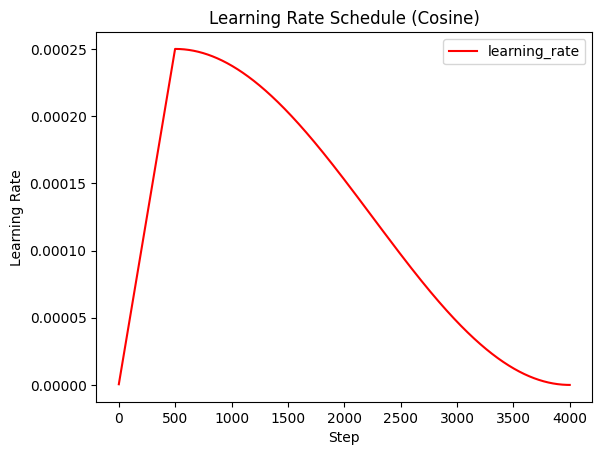

In [63]:
# 이 셀은 learning-rate schedule을 시각화합니다.
# compute lr
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

# draw
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()


이제 모델을 실제로 빌드해 봅시다.


In [64]:
# 이 셀은 torchinfo를 설치합니다.
# 모델 생성을 위한 라이브러리 설치
%pip install -q torchinfo


Note: you may need to restart the kernel to use updated packages.


f:\code\AIFFEL\AIFFEL_study\.venv\Scripts\python.exe: No module named pip


In [65]:
# 이 셀은 mini BERT pretrain 모델을 만들고 파라미터 수를 확인합니다.
try:
    from torchinfo import summary
except ImportError:
    summary = None
    print("torchinfo가 설치되어 있지 않습니다. `%pip install torchinfo`를 실행하세요.")

config.n_seq = 128
config.n_vocab = int(globals().get("REAL_VOCAB_SIZE", config.n_vocab))
config.i_pad = 0

pre_train_model = build_model_pre_train(config)
num_params = sum(p.numel() for p in pre_train_model.parameters() if p.requires_grad)
print("model n_vocab:", config.n_vocab)
print(f"trainable parameters: {num_params:,} ({num_params / 1_000_000:.2f}M)")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model.to(device)

enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(device)

if summary is not None:
    summary(pre_train_model, input_data=(enc_tokens_example, segments_example))


model n_vocab: 8000
trainable parameters: 968,562 (0.97M)


이제 본격적으로 학습을 진행합니다. 1 Epoch만 학습하는 데도 10분 이상의 상당한 시간이 소요될 것입니다. 메모리 오류가 날 수 있으니 배치 사이즈에도 유의해 주세요. 우리는 전체 데이터셋 중의 1/7 수준인 128,000건만 로딩해서 사용 중이라는 것을 기억합시다.

optimizer는 Adam을 사용하고, MLM과 NSP에 대한 loss와 accuracy를 알 수 있도록 하였습니다.


In [66]:
# 이 셀은 optimizer와 learning-rate scheduler를 실제 학습 step 수에 맞게 준비합니다.
epochs = int(os.environ.get("BERT_PRETRAIN_EPOCHS", "10"))
batch_size = int(os.environ.get("BERT_PRETRAIN_BATCH_SIZE", "8"))

train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("epochs:", epochs)
print("batch_size:", batch_size)
print("train_steps:", train_steps)

optimizer = optim.Adam(pre_train_model.parameters(), lr=0.0)
learning_rate_scheduler = CosineSchedule(
    optimizer=optimizer,
    train_steps=train_steps,
    warmup_steps=max(1, min(100, train_steps // 10 if train_steps >= 10 else 1)),
    max_lr=1e-4,
)

loss_fn_nsp = nn.CrossEntropyLoss()


epochs: 10
batch_size: 64
train_steps: 142660


학습시킨 모델을 콜백 함수를 사용해 저장하고, 시각화해 봅시다.


In [ ]:
from tqdm import tqdm
import time

from torch.amp import autocast, GradScaler

# 이 셀은 mini BERT를 실제 pretrain 데이터로 학습하고 epoch별 지표와 모델을 저장합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# np.memmap 전체를 GPU에 올리지 않고, DataLoader batch마다 device로 이동합니다.
pre_train_inputs_t = [torch.from_numpy(np.asarray(x)) for x in pre_train_inputs]
pre_train_labels_t = [torch.from_numpy(np.asarray(x)) for x in pre_train_labels]

train_dataset = TensorDataset(
    pre_train_inputs_t[0],
    pre_train_inputs_t[1],
    pre_train_labels_t[0],
    pre_train_labels_t[1],
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=(device.type == "cuda"),
    num_workers=2,
)

# train_dataloader = DataLoader(
#     train_dataset,
#     batch_size=batch_size,
#     shuffle=True,
#     pin_memory=(device.type == "cuda"),
# )

pre_train_model.to(device)
scaler = GradScaler('cuda', enabled=torch.cuda.is_available())

history = {
    "nsp_loss": [], "mlm_loss": [],
    "nsp_acc": [],  "mlm_acc": [],
    "total_loss": [],
}
#history = {"nsp_loss": [], "mlm_loss": [], "nsp_acc": [], "mlm_acc": []}

os.makedirs("work", exist_ok=True)

t_total = time.time()
print(f"학습시작: {epochs} epochs, batch={batch_size}")
print(f"AMP: {'ON (fp16 forward)' if torch.cuda.is_available() else 'OFF (cpu fallback)'}")
print()

for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0.0
    total_nsp_loss = 0.0
    total_mlm_loss = 0.0
    total_nsp_acc = 0.0
    total_mlm_acc = 0.0
    
    t_ep = time.time()
    
    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in pbar:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        enc_tokens_batch = enc_tokens_batch.to(device, dtype=torch.long, non_blocking=True)
        segments_batch = segments_batch.to(device, dtype=torch.long, non_blocking=True)
        labels_nsp_batch = labels_nsp_batch.to(device, dtype=torch.long, non_blocking=True)
        labels_mlm_batch = labels_mlm_batch.to(device, dtype=torch.long, non_blocking=True)

        optimizer.zero_grad()
        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = lm_loss(labels_mlm_batch, logits_mlm, ignore_index=0, scale=20.0)
        total_loss_batch = loss_nsp + loss_mlm

        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        # total_loss_batch.backward()
        # optimizer.step()
        # learning_rate_scheduler.step()
        
        scaler.scale(total_loss_batch).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(pre_train_model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        learning_rate_scheduler.step()

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc_value = lm_acc(labels_mlm_batch, logits_mlm, ignore_index=0)
        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc_value.item()

    num_batches = len(train_dataloader)
    if num_batches == 0:
        raise RuntimeError("학습 batch가 0개입니다. pretrain 데이터 생성/로딩 결과를 확인해야 합니다.")

    history["nsp_loss"].append(total_nsp_loss / num_batches)
    history["mlm_loss"].append(total_mlm_loss / num_batches)
    history["nsp_acc"].append(total_nsp_acc / num_batches)
    history["mlm_acc"].append(total_mlm_acc / num_batches)
    history["total_loss"].append(total_loss / num_batches)

    # print(f"Epoch {epoch + 1}/{epochs} - Loss: {total_loss / num_batches:.4f}, "
    #       f"NSP Loss: {total_nsp_loss / num_batches:.4f}, MLM Loss: {total_mlm_loss / num_batches:.4f}, "
    #       f"NSP Accuracy: {total_nsp_acc / num_batches:.4f}, MLM Accuracy: {total_mlm_acc / num_batches:.4f}")
    print(f"epoch {epoch+1}/{epochs} | "
          f"total {history['total_loss'][-1]:.4f} | "
          f"NSP loss {history['nsp_loss'][-1]:.4f} acc {history['nsp_acc'][-1]:.4f} | "
          f"MLM loss {history['mlm_loss'][-1]:.4f} acc {history['mlm_acc'][-1]:.4f} | "
          f"에폭 {time.time()-t_ep:.1f}s | 누적 {time.time()-t_total:.1f}s")

    torch.save(pre_train_model.state_dict(), f"work/mini_bert_pre_train_epoch_{epoch + 1}.pt")


학습시작: 10 epochs, batch=64
AMP: ON (fp16 forward)

epoch 1/10 | total 148.4982 | NSP loss 0.4719 acc 0.7139 | MLM loss 148.0263 acc 0.0339 | 에폭 227.7s | 누적 227.7s
epoch 2/10 | total 137.4496 | NSP loss 0.4428 acc 0.7313 | MLM loss 137.0068 acc 0.0669 | 에폭 246.8s | 누적 474.4s
epoch 3/10 | total 128.8008 | NSP loss 0.4300 acc 0.7363 | MLM loss 128.3708 acc 0.1076 | 에폭 243.0s | 누적 717.4s
epoch 4/10 | total 120.2992 | NSP loss 0.4271 acc 0.7369 | MLM loss 119.8721 acc 0.1364 | 에폭 231.8s | 누적 949.3s
epoch 5/10 | total 113.8674 | NSP loss 0.4241 acc 0.7382 | MLM loss 113.4433 acc 0.1578 | 에폭 232.5s | 누적 1181.7s
epoch 6/10 | total 110.7278 | NSP loss 0.4214 acc 0.7396 | MLM loss 110.3064 acc 0.1698 | 에폭 231.4s | 누적 1413.1s
epoch 7/10 | total 108.8908 | NSP loss 0.4197 acc 0.7406 | MLM loss 108.4711 acc 0.1775 | 에폭 228.3s | 누적 1641.4s
epoch 8/10 | total 107.8549 | NSP loss 0.4186 acc 0.7414 | MLM loss 107.4363 acc 0.1822 | 에폭 217.4s | 누적 1858.8s
epoch 9/10 | total 107.3577 | NSP loss 0.4184 acc 

       nsp_loss    mlm_loss   nsp_acc   mlm_acc  total_loss
epoch                                                      
1      0.471930  148.026297  0.713933  0.033914  148.498227
2      0.442805  137.006796  0.731281  0.066929  137.449602
3      0.430010  128.370816  0.736254  0.107650  128.800826
4      0.427065  119.872116  0.736878  0.136399  120.299180
5      0.424112  113.443315  0.738228  0.157755  113.867427
6      0.421409  110.306387  0.739588  0.169831  110.727796
7      0.419740  108.471066  0.740608  0.177527  108.890805
8      0.418620  107.436316  0.741444  0.182166  107.854935
9      0.418350  106.939303  0.741336  0.184327  107.357653
10     0.418381  106.777421  0.741581  0.185072  107.195802


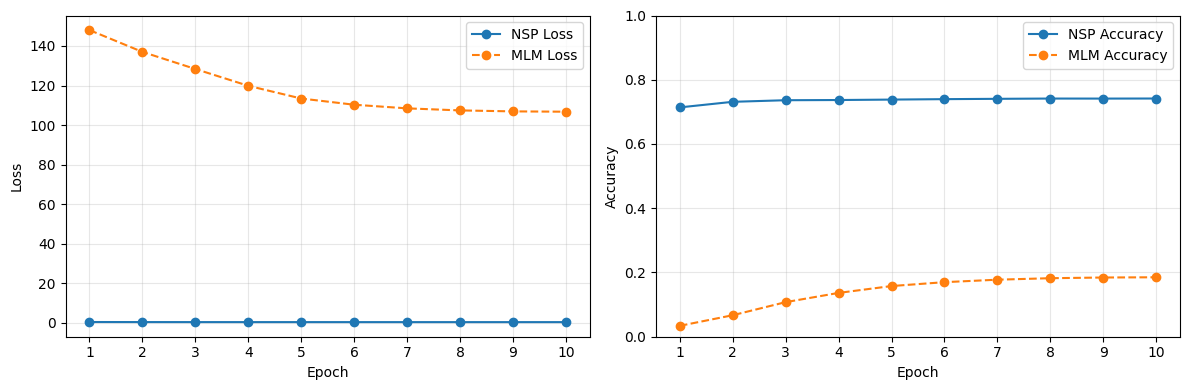

In [68]:
# 이 셀은 학습 결과를 시각화합니다.
import matplotlib.pyplot as plt
import pandas as pd

# training result
if len(history["nsp_loss"]) == 0:
    raise RuntimeError("history가 비어 있습니다. 바로 위 학습 셀이 정상적으로 실행됐는지 확인해야 합니다.")

history_df = pd.DataFrame(history)
history_df.index = range(1, len(history_df) + 1)
history_df.index.name = "epoch"
print(history_df)

x = history_df.index.to_list()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x, history_df["nsp_loss"], marker="o", label="NSP Loss")
plt.plot(x, history_df["mlm_loss"], marker="o", linestyle="--", label="MLM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(x)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x, history_df["nsp_acc"], marker="o", label="NSP Accuracy")
plt.plot(x, history_df["mlm_acc"], marker="o", linestyle="--", label="MLM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(x)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Mecab + ko_32000 추가 실험

아래 셀들은 기존 `ko_8000` 실험 코드를 수정하지 않고, Mecab 형태소 corpus로 `ko_32000` SentencePiece 모델을 새로 학습한 뒤 형태소 경계 기준 MLM masking을 적용하는 별도 실험입니다.


In [75]:
# Mecab 형태소 corpus를 만들고 vocab size 32000 SentencePiece 모델을 학습합니다.
from pathlib import Path
import os
import json
import random
import math
import time
import copy
import numpy as np
import sentencepiece as spm
from tqdm.auto import tqdm

try:
    import mecab as mecab_module
    mecab_tokenizer = mecab_module.MeCab()
except Exception:
    from konlpy.tag import Mecab
    mecab_tokenizer = Mecab()

MECAB_MODEL_PREFIX = "ko_32000"
MECAB_VOCAB_SIZE = 32000

mecab_data_dir = Path("data")
mecab_work_dir = Path("work")
mecab_model_dir = Path("models")
for path in (mecab_data_dir, mecab_work_dir, mecab_model_dir):
    path.mkdir(parents=True, exist_ok=True)

mecab_source_corpus = Path(globals().get("corpus_path", os.environ.get("BERT_PRETRAIN_CORPUS_FILE", mecab_data_dir / "kowiki.txt")))
if not mecab_source_corpus.exists():
    mecab_source_corpus = Path(globals().get("corpus_file", mecab_data_dir / "kowiki.txt"))
if not mecab_source_corpus.exists():
    raise FileNotFoundError(f"corpus 파일을 찾을 수 없습니다: {mecab_source_corpus}")

mecab_corpus_path = mecab_data_dir / "kowiki_mecab.txt"
mecab_model_path = mecab_data_dir / f"{MECAB_MODEL_PREFIX}.model"
mecab_vocab_path = mecab_data_dir / f"{MECAB_MODEL_PREFIX}.vocab"

def make_mecab_corpus(in_path, out_path, tokenizer, force=False):
    if out_path.exists() and not force:
        print("Mecab corpus already exists:", out_path)
        return out_path

    with open(in_path, "r", encoding="utf-8") as count_f:
        total_lines = sum(1 for _ in count_f)

    with open(in_path, "r", encoding="utf-8") as in_f, open(out_path, "w", encoding="utf-8") as out_f:
        for line in tqdm(in_f, total=total_lines, desc="Mecab corpus"):
            line = line.strip()
            if line:
                out_f.write(" ".join(tokenizer.morphs(line)) + "\n")
            else:
                out_f.write("\n")
    return out_path

make_mecab_corpus(
    mecab_source_corpus,
    mecab_corpus_path,
    mecab_tokenizer,
    force=os.environ.get("MECAB_FORCE_REBUILD_CORPUS", "0") == "1",
)

mecab_existing_vocab_size = None
mecab_needs_sp_train = os.environ.get("MECAB_FORCE_RETRAIN_SP", "0") == "1" or not mecab_model_path.exists()
if mecab_model_path.exists() and not mecab_needs_sp_train:
    probe_vocab = spm.SentencePieceProcessor()
    probe_vocab.load(str(mecab_model_path))
    mecab_existing_vocab_size = probe_vocab.get_piece_size()
    if mecab_existing_vocab_size != MECAB_VOCAB_SIZE:
        print(f"Existing {MECAB_MODEL_PREFIX}.model has vocab_size={mecab_existing_vocab_size}; retraining to {MECAB_VOCAB_SIZE}.")
        mecab_needs_sp_train = True

if mecab_needs_sp_train:
    for stale_path in (mecab_model_path, mecab_vocab_path):
        if stale_path.exists():
            stale_path.unlink()
    print(f"Training SentencePiece: prefix={MECAB_MODEL_PREFIX}, vocab_size={MECAB_VOCAB_SIZE}")
    spm.SentencePieceTrainer.train(
        f"--input={mecab_corpus_path} "
        f"--model_prefix={mecab_data_dir / MECAB_MODEL_PREFIX} "
        f"--vocab_size={MECAB_VOCAB_SIZE} "
        "--model_type=bpe "
        "--character_coverage=0.9995 "
        "--max_sentence_length=999999 "
        "--pad_id=0 --pad_piece=[PAD] "
        "--unk_id=1 --unk_piece=[UNK] "
        "--bos_id=2 --bos_piece=[BOS] "
        "--eos_id=3 --eos_piece=[EOS] "
        "--user_defined_symbols=[SEP],[CLS],[MASK] "
        "--hard_vocab_limit=false"
    )
else:
    print(f"SentencePiece model already exists: {mecab_model_path} (vocab_size={mecab_existing_vocab_size})")

vocab_mecab = spm.SentencePieceProcessor()
vocab_mecab.load(str(mecab_model_path))
REAL_MECAB_VOCAB_SIZE = vocab_mecab.get_piece_size()

print("source corpus:", mecab_source_corpus)
print("mecab corpus :", mecab_corpus_path)
print("model prefix :", MECAB_MODEL_PREFIX)
print("real vocab   :", REAL_MECAB_VOCAB_SIZE)
print("[SEP], [CLS], [MASK]:", vocab_mecab.piece_to_id("[SEP]"), vocab_mecab.piece_to_id("[CLS]"), vocab_mecab.piece_to_id("[MASK]"))


Mecab corpus already exists: data\kowiki_mecab.txt
Existing ko_32000.model has vocab_size=8007; retraining to 32000.
Training SentencePiece: prefix=ko_32000, vocab_size=32000
source corpus: f:\code\AIFFEL\AIFFEL_study\BERT_pretrained\data\kowiki.txt
mecab corpus : data\kowiki_mecab.txt
model prefix : ko_32000
real vocab   : 32000
[SEP], [CLS], [MASK]: 4 5 6


In [76]:
# Mecab 형태소 경계를 기준으로 MLM mask를 만들고 ko_32000 JSONL pretrain dataset을 생성합니다.
if "trim_tokens" not in globals():
    def trim_tokens(tokens_a, tokens_b, max_seq):
        while len(tokens_a) + len(tokens_b) > max_seq:
            if len(tokens_a) > len(tokens_b):
                tokens_a.pop(0)
            else:
                tokens_b.pop()

def build_mecab_morph_candidate_indices(tokens):
    """Mecab으로 공백 분리된 형태소가 SentencePiece에서 다시 쪼개진 조각들을 한 후보로 묶습니다."""
    cand_idx = []
    current = []
    for i, token in enumerate(tokens):
        if token in ("[CLS]", "[SEP]"):
            if current:
                cand_idx.append(current)
                current = []
            continue

        if token.startswith("▁") and current:
            cand_idx.append(current)
            current = [i]
        else:
            current.append(i)

    if current:
        cand_idx.append(current)
    return cand_idx

def create_mecab_mlm_mask(tokens, mask_cnt, vocab_list, rng=None):
    """Mecab 형태소 단위 whole-morph masking에 BERT의 80/10/10 masking 규칙을 적용합니다."""
    rng = rng or random
    tokens = list(tokens)
    valid_token_indices = [i for i, token in enumerate(tokens) if token not in ("[CLS]", "[SEP]")]
    if not valid_token_indices or mask_cnt <= 0:
        return tokens, [], []

    mask_cnt = min(mask_cnt, len(valid_token_indices))
    cand_idx = build_mecab_morph_candidate_indices(tokens)
    rng.shuffle(cand_idx)

    mask_lms = []
    covered = set()

    def replace_token(index):
        dice = rng.random()
        if dice < 0.8:
            return "[MASK]"
        if dice < 0.9:
            return rng.choice(vocab_list)
        return tokens[index]

    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if any(index in covered for index in index_set):
            continue
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue

        for index in index_set:
            mask_lms.append({"index": index, "label": tokens[index]})
            covered.add(index)
            tokens[index] = replace_token(index)

    if len(mask_lms) < mask_cnt:
        fallback = [index for index in valid_token_indices if index not in covered]
        rng.shuffle(fallback)
        for index in fallback[: mask_cnt - len(mask_lms)]:
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = replace_token(index)

    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]
    return tokens, mask_idx, mask_label

def create_mecab_pretrain_instances(vocab_obj, doc, n_seq, mask_prob, vocab_list, rng=None):
    rng = rng or random
    max_seq = n_seq - 3
    instances = []
    current_chunk = []
    current_length = 0

    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])

        if len(current_chunk) > 1 and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = rng.randrange(1, len(current_chunk))
            tokens_a = [piece for line in current_chunk[:a_end] for piece in line]
            tokens_b = [piece for line in current_chunk[a_end:] for piece in line]

            if rng.random() < 0.5:
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1

            trim_tokens(tokens_a, tokens_b, max_seq)
            if not tokens_a or not tokens_b:
                current_chunk = []
                current_length = 0
                continue

            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            mask_cnt = max(1, int(round((len(tokens) - 3) * mask_prob)))
            tokens, mask_idx, mask_label = create_mecab_mlm_mask(tokens, mask_cnt, vocab_list, rng=rng)

            instances.append({
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label,
            })
            current_chunk = []
            current_length = 0

    return instances

def make_mecab_pretrain_data(vocab_obj, in_file, out_file, n_seq, mask_prob=0.15, seed=1234):
    out_file = Path(out_file)
    out_file.parent.mkdir(parents=True, exist_ok=True)
    rng = random.Random(seed)
    local_vocab_list = [
        vocab_obj.id_to_piece(token_id)
        for token_id in range(7, vocab_obj.get_piece_size())
        if not vocab_obj.is_unknown(token_id)
    ]

    with open(in_file, "r", encoding="utf-8") as count_f:
        line_cnt = sum(1 for _ in count_f)

    with open(in_file, "r", encoding="utf-8") as in_f, open(out_file, "w", encoding="utf-8") as out_f:
        doc = []
        for line in tqdm(in_f, total=line_cnt, desc="Mecab JSONL"):
            line = line.strip()
            if line == "":
                if doc:
                    for instance in create_mecab_pretrain_instances(vocab_obj, doc, n_seq, mask_prob, local_vocab_list, rng=rng):
                        out_f.write(json.dumps(instance, ensure_ascii=False) + "\n")
                    doc = []
            else:
                pieces = vocab_obj.encode_as_pieces(line)
                if pieces:
                    doc.append(pieces)

        if doc:
            for instance in create_mecab_pretrain_instances(vocab_obj, doc, n_seq, mask_prob, local_vocab_list, rng=rng):
                out_f.write(json.dumps(instance, ensure_ascii=False) + "\n")

    return out_file

mecab_pretrain_json_path = mecab_work_dir / "bert_pre_train_ko_32000_mecab.json"
mecab_rebuild_json = (
    os.environ.get("MECAB_FORCE_REBUILD_JSON", "0") == "1"
    or not mecab_pretrain_json_path.exists()
    or mecab_pretrain_json_path.stat().st_mtime < mecab_model_path.stat().st_mtime
)
if mecab_rebuild_json:
    if mecab_pretrain_json_path.exists():
        print("Rebuilding Mecab JSONL because tokenizer/model changed:", mecab_pretrain_json_path)
    make_mecab_pretrain_data(vocab_mecab, mecab_corpus_path, mecab_pretrain_json_path, 128)
else:
    print("Mecab JSONL already exists:", mecab_pretrain_json_path)

with open(mecab_pretrain_json_path, "r", encoding="utf-8") as f:
    mecab_total = sum(1 for _ in f)

print("mecab JSONL:", mecab_pretrain_json_path)
print("instances :", mecab_total)

with open(mecab_pretrain_json_path, "r", encoding="utf-8") as f:
    sample = json.loads(next(f))

print("sample tokens:", sample["tokens"][:40])
print("sample mask_idx:", sample["mask_idx"])
print("sample mask_label:", sample["mask_label"])


Rebuilding Mecab JSONL because tokenizer/model changed: work\bert_pre_train_ko_32000_mecab.json


Mecab JSONL:   0%|          | 0/3957761 [00:00<?, ?it/s]

mecab JSONL: work\bert_pre_train_ko_32000_mecab.json
instances : 901455
sample tokens: ['[CLS]', '▁카터', '▁는', '▁조지', '▁아주', '▁섬', '터', '▁카운티', '▁재능', '▁레인', '스', '▁마을', '▁에서', '▁태어났', '▁다', '▁.', '▁조지', '▁아', '▁공과', '▁단발', '▁를', '▁졸업', '▁하', '[MASK]', '▁다', '▁.', '▁그', '▁후', '▁해군', '▁에', '▁들어가', '▁전함', '▁·', '▁원자력', '▁·', '▁감사원', '▁의', '▁승무원', '▁으로', '[MASK]']
sample mask_idx: [8, 19, 23, 35, 39, 51, 53, 55, 58, 67, 79, 80, 81, 94, 97, 102, 109, 110, 117]
sample mask_label: ['▁플', '▁대학교', '▁였', '▁잠수함', '▁일', '▁하', '▁고', '▁땅콩', '▁등', '▁었', '▁Pe', 'an', 'ut', '▁"', '▁카터', '▁년', '▁는', '▁민주당', '▁(']


In [77]:
# ko_32000 Mecab dataset을 memmap으로 로딩하고 새 mini BERT 모델을 준비합니다.
import torch
import torch.nn as nn
import torch.optim as optim
import time
import uuid
from torch.utils.data import TensorDataset, DataLoader

def parse_optional_count(value):
    if value is None:
        return None
    value = str(value).strip()
    if value.lower() in ("", "0", "none", "all", "-1"):
        return None
    return int(value)

# 기본값은 전체 데이터입니다. 빠른 테스트만 하고 싶으면 아래 값을 parse_optional_count("4096")처럼 바꾸세요.
mecab_train_count = None
mecab_memmap_dir = Path("work") / f"memmap_ko_32000_mecab_{time.strftime('%Y%m%d_%H%M%S')}_{uuid.uuid4().hex[:6]}"

pre_train_inputs_mecab, pre_train_labels_mecab = load_pre_train_data(
    vocab_mecab,
    mecab_pretrain_json_path,
    128,
    count=mecab_train_count,
    memmap_dir=str(mecab_memmap_dir),
    #memmap_dir="work/memmap_ko_32000_mecab",
)

config_mecab = Config(dict(config))
config_mecab.n_seq = 128
config_mecab.n_vocab = REAL_MECAB_VOCAB_SIZE
config_mecab.i_pad = 0

pre_train_model_mecab = build_model_pre_train(config_mecab)
mecab_num_params = sum(p.numel() for p in pre_train_model_mecab.parameters() if p.requires_grad)

mecab_epochs = int(os.environ.get("MECAB_PRETRAIN_EPOCHS", os.environ.get("BERT_PRETRAIN_EPOCHS", "10")))
mecab_batch_size = int(os.environ.get("MECAB_PRETRAIN_BATCH_SIZE", os.environ.get("BERT_PRETRAIN_BATCH_SIZE", "8")))
mecab_train_steps = math.ceil(len(pre_train_inputs_mecab[0]) / mecab_batch_size) * mecab_epochs

mecab_optimizer = optim.Adam(pre_train_model_mecab.parameters(), lr=0.0)
mecab_learning_rate_scheduler = CosineSchedule(
    optimizer=mecab_optimizer,
    train_steps=mecab_train_steps,
    warmup_steps=max(1, min(100, mecab_train_steps // 10 if mecab_train_steps >= 10 else 1)),
    max_lr=1e-4,
)
mecab_loss_fn_nsp = nn.CrossEntropyLoss()

print("loaded train_count:", len(pre_train_inputs_mecab[0]))
print("train_count limit:", "ALL" if mecab_train_count is None else mecab_train_count)
print("model n_vocab    :", config_mecab.n_vocab)
print(f"trainable params : {mecab_num_params:,} ({mecab_num_params / 1_000_000:.2f}M)")
print("epochs           :", mecab_epochs)
print("batch_size       :", mecab_batch_size)
print("train_steps      :", mecab_train_steps)


  0%|          | 0/901455 [00:00<?, ?it/s]

loaded train_count: 901455
train_count limit: ALL
model n_vocab    : 32000
trainable params : 2,888,562 (2.89M)
epochs           : 10
batch_size       : 64
train_steps      : 140860


In [78]:
# ko_32000 + Mecab 형태소 masking 모델 학습 셀입니다.
from torch.amp import autocast, GradScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pre_train_inputs_mecab_t = [torch.from_numpy(np.asarray(x)) for x in pre_train_inputs_mecab]
pre_train_labels_mecab_t = [torch.from_numpy(np.asarray(x)) for x in pre_train_labels_mecab]

train_dataset_mecab = TensorDataset(
    pre_train_inputs_mecab_t[0],
    pre_train_inputs_mecab_t[1],
    pre_train_labels_mecab_t[0],
    pre_train_labels_mecab_t[1],
)
train_dataloader_mecab = DataLoader(
    train_dataset_mecab,
    batch_size=mecab_batch_size,
    shuffle=True,
    pin_memory=(device.type == "cuda"),
    num_workers=0,
)

pre_train_model_mecab.to(device)
mecab_scaler = GradScaler("cuda", enabled=torch.cuda.is_available())

history_mecab = {
    "nsp_loss": [], "mlm_loss": [],
    "nsp_acc": [], "mlm_acc": [],
    "total_loss": [],
}

t_total = time.time()
print(f"Mecab ko_32000 학습시작: {mecab_epochs} epochs, batch={mecab_batch_size}")
print(f"AMP: {'ON (fp16 forward)' if torch.cuda.is_available() else 'OFF (cpu fallback)'}")
print()

for epoch in range(mecab_epochs):
    pre_train_model_mecab.train()
    total_loss = 0.0
    total_nsp_loss = 0.0
    total_mlm_loss = 0.0
    total_nsp_acc = 0.0
    total_mlm_acc = 0.0

    t_ep = time.time()
    pbar = tqdm(
        train_dataloader_mecab,
        desc=f"Mecab ko_32000 {epoch + 1}/{mecab_epochs}",
        colour="cyan",
        dynamic_ncols=True,
    )

    for batch in pbar:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        enc_tokens_batch = enc_tokens_batch.to(device, dtype=torch.long, non_blocking=True)
        segments_batch = segments_batch.to(device, dtype=torch.long, non_blocking=True)
        labels_nsp_batch = labels_nsp_batch.to(device, dtype=torch.long, non_blocking=True)
        labels_mlm_batch = labels_mlm_batch.to(device, dtype=torch.long, non_blocking=True)

        mecab_optimizer.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=torch.cuda.is_available()):
            logits_nsp, logits_mlm = pre_train_model_mecab(enc_tokens_batch, segments_batch)
            loss_nsp = mecab_loss_fn_nsp(logits_nsp, labels_nsp_batch)
            loss_mlm = lm_loss(labels_mlm_batch, logits_mlm, ignore_index=0, scale=20.0)
            total_loss_batch = loss_nsp + loss_mlm

        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        mecab_scaler.scale(total_loss_batch).backward()
        mecab_scaler.unscale_(mecab_optimizer)
        torch.nn.utils.clip_grad_norm_(pre_train_model_mecab.parameters(), max_norm=1.0)
        mecab_scaler.step(mecab_optimizer)
        mecab_scaler.update()
        mecab_learning_rate_scheduler.step()

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc_value = lm_acc(labels_mlm_batch, logits_mlm, ignore_index=0)
        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc_value.item()
        pbar.set_postfix(loss=f"{total_loss_batch.item():.3f}", mlm_acc=f"{mlm_acc_value.item():.3f}")

    num_batches = len(train_dataloader_mecab)
    if num_batches == 0:
        raise RuntimeError("Mecab 학습 batch가 0개입니다. 데이터 로딩 결과를 확인하세요.")

    history_mecab["nsp_loss"].append(total_nsp_loss / num_batches)
    history_mecab["mlm_loss"].append(total_mlm_loss / num_batches)
    history_mecab["nsp_acc"].append(total_nsp_acc / num_batches)
    history_mecab["mlm_acc"].append(total_mlm_acc / num_batches)
    history_mecab["total_loss"].append(total_loss / num_batches)

    print(f"epoch {epoch + 1}/{mecab_epochs} | "
          f"total {history_mecab['total_loss'][-1]:.4f} | "
          f"NSP loss {history_mecab['nsp_loss'][-1]:.4f} acc {history_mecab['nsp_acc'][-1]:.4f} | "
          f"MLM loss {history_mecab['mlm_loss'][-1]:.4f} acc {history_mecab['mlm_acc'][-1]:.4f} | "
          f"에폭 {time.time() - t_ep:.1f}s | 누적 {time.time() - t_total:.1f}s")

    torch.save(pre_train_model_mecab.state_dict(), f"work/mini_bert_mecab_ko_32000_epoch_{epoch + 1}.pt")

history_mecab_df = pd.DataFrame(history_mecab, index=range(1, len(history_mecab["total_loss"]) + 1))
history_mecab_df.index.name = "epoch"
print(history_mecab_df)


Mecab ko_32000 학습시작: 10 epochs, batch=64
AMP: ON (fp16 forward)



Mecab ko_32000 1/10:   0%|          | 0/14086 [00:00<?, ?it/s]

epoch 1/10 | total 143.6902 | NSP loss 0.4565 acc 0.7210 | MLM loss 143.2337 acc 0.0587 | 에폭 396.0s | 누적 396.0s


Mecab ko_32000 2/10:   0%|          | 0/14086 [00:00<?, ?it/s]

epoch 2/10 | total 128.8686 | NSP loss 0.4279 acc 0.7399 | MLM loss 128.4407 acc 0.1279 | 에폭 399.8s | 누적 795.8s


...

epoch 8/10 | total 86.5317 | NSP loss 0.4080 acc 0.7511 | MLM loss 86.1237 acc 0.3344 | 에폭 377.0s | 누적 3076.1s


Mecab ko_32000 9/10:   0%|          | 0/14086 [00:00<?, ?it/s]

epoch 9/10 | total 85.9138 | NSP loss 0.4073 acc 0.7515 | MLM loss 85.5065 acc 0.3373 | 에폭 418.8s | 누적 3495.0s


Mecab ko_32000 10/10:   0%|          | 0/14086 [00:00<?, ?it/s]

epoch 10/10 | total 85.7039 | NSP loss 0.4072 acc 0.7517 | MLM loss 85.2967 acc 0.3383 | 에폭 418.0s | 누적 3913.0s
       nsp_loss    mlm_loss   nsp_acc   mlm_acc  total_loss
epoch                                                      
1      0.456536  143.233662  0.720993  0.058655  143.690198
2      0.427895  128.440681  0.739874  0.127888  128.868576
3      0.423851  112.624791  0.741178  0.198019  113.048643
4      0.416948  101.324438  0.746169  0.258114  101.741387
5      0.413515   94.050561  0.748038  0.295209   94.464077
6      0.410969   89.814864  0.749329  0.316506   90.225833
7      0.409385   87.420197  0.750294  0.328183   87.829583
8      0.408023   86.123661  0.751108  0.334370   86.531684
9      0.407301   85.506492  0.751545  0.337316   85.913793
10     0.407174   85.296689  0.751732  0.338258   85.703864


## 78번 셀 결과 시각화

`history_mecab_df`에 저장된 Mecab + `ko_32000` 실험 결과를 loss와 accuracy 관점에서 확인합니다.


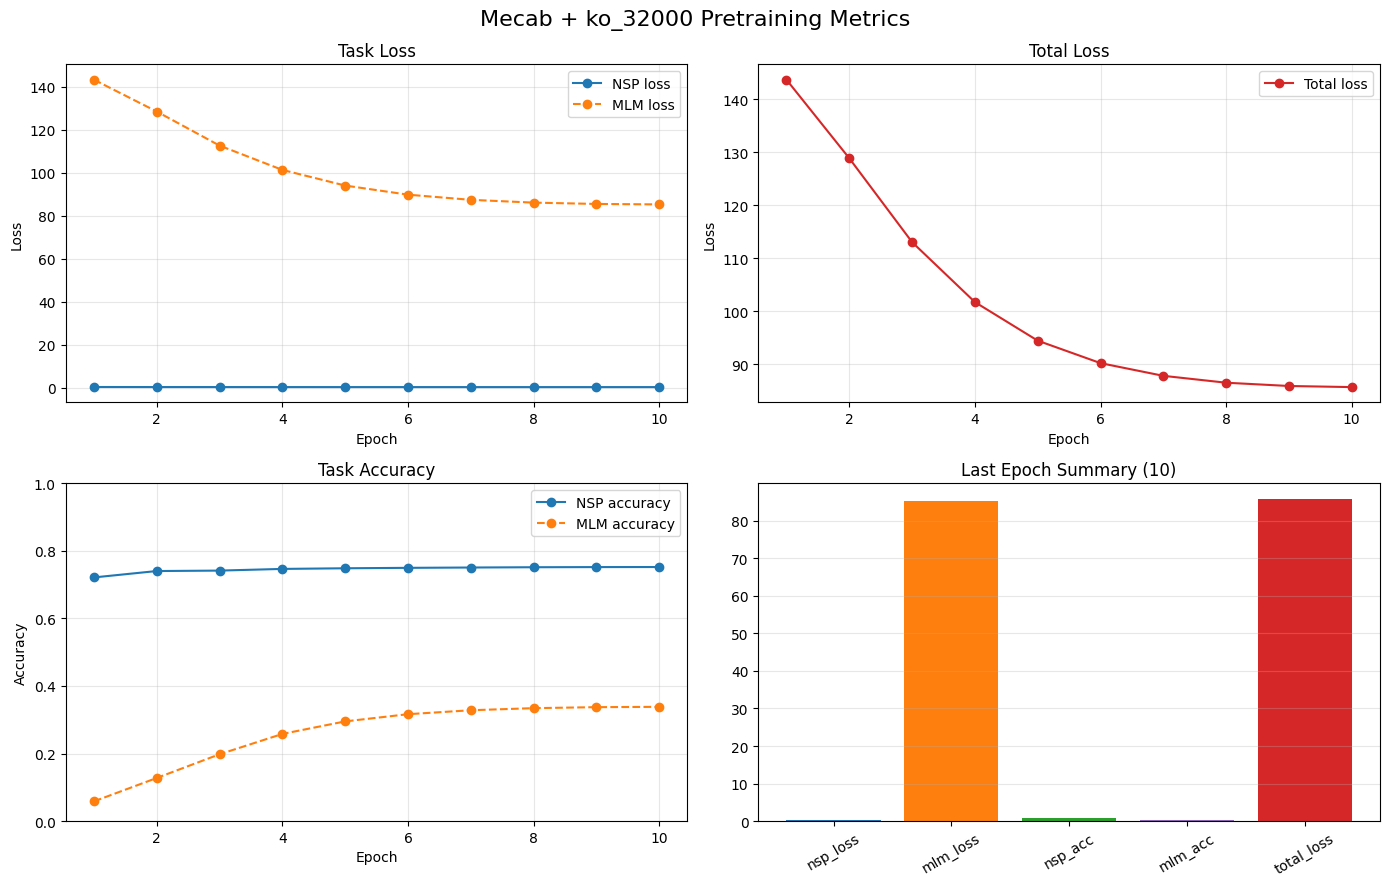

,nsp_loss,mlm_loss,nsp_acc,mlm_acc,total_loss
epoch,,,,,
1,0.456536,143.233662,0.720993,0.058655,143.690198
2,0.427895,128.440681,0.739874,0.127888,128.868576
3,0.423851,112.624791,0.741178,0.198019,113.048643
4,0.416948,101.324438,0.746169,0.258114,101.741387
5,0.413515,94.050561,0.748038,0.295209,94.464077
6,0.410969,89.814864,0.749329,0.316506,90.225833
7,0.409385,87.420197,0.750294,0.328183,87.829583
8,0.408023,86.123661,0.751108,0.334370,86.531684
9,0.407301,85.506492,0.751545,0.337316,85.913793


In [79]:
# 78번 셀 결과: Mecab + ko_32000 학습 지표 시각화
import pandas as pd
import matplotlib.pyplot as plt

if "history_mecab_df" not in globals():
    if "history_mecab" in globals() and len(history_mecab.get("total_loss", [])) > 0:
        history_mecab_df = pd.DataFrame(history_mecab, index=range(1, len(history_mecab["total_loss"]) + 1))
        history_mecab_df.index.name = "epoch"
    else:
        raise RuntimeError("history_mecab_df가 없습니다. 78번 학습 셀을 먼저 실행해주세요.")

required_cols = ["nsp_loss", "mlm_loss", "nsp_acc", "mlm_acc", "total_loss"]
missing_cols = [col for col in required_cols if col not in history_mecab_df.columns]
if missing_cols:
    raise RuntimeError(f"history_mecab_df에 필요한 컬럼이 없습니다: {missing_cols}")
if history_mecab_df.empty:
    raise RuntimeError("history_mecab_df가 비어 있습니다. 78번 학습 셀 결과를 확인해주세요.")

mecab_plot_df = history_mecab_df.copy()
x = mecab_plot_df.index.to_list()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Mecab + ko_32000 Pretraining Metrics", fontsize=16)

axes[0, 0].plot(x, mecab_plot_df["nsp_loss"], marker="o", label="NSP loss")
axes[0, 0].plot(x, mecab_plot_df["mlm_loss"], marker="o", linestyle="--", label="MLM loss")
axes[0, 0].set_title("Task Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(x, mecab_plot_df["total_loss"], marker="o", color="tab:red", label="Total loss")
axes[0, 1].set_title("Total Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(x, mecab_plot_df["nsp_acc"], marker="o", label="NSP accuracy")
axes[1, 0].plot(x, mecab_plot_df["mlm_acc"], marker="o", linestyle="--", label="MLM accuracy")
axes[1, 0].set_title("Task Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

last_metrics = mecab_plot_df.iloc[-1][required_cols]
axes[1, 1].bar(last_metrics.index, last_metrics.values, color=["tab:blue", "tab:orange", "tab:green", "tab:purple", "tab:red"])
axes[1, 1].set_title(f"Last Epoch Summary ({mecab_plot_df.index[-1]})")
axes[1, 1].tick_params(axis="x", rotation=30)
axes[1, 1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

display(mecab_plot_df)


## 68번 셀과 78번 셀 결과 비교

기존 `ko_8000` baseline의 `history_df`와 Mecab + `ko_32000` 실험의 `history_mecab_df`를 같은 축에서 비교합니다.


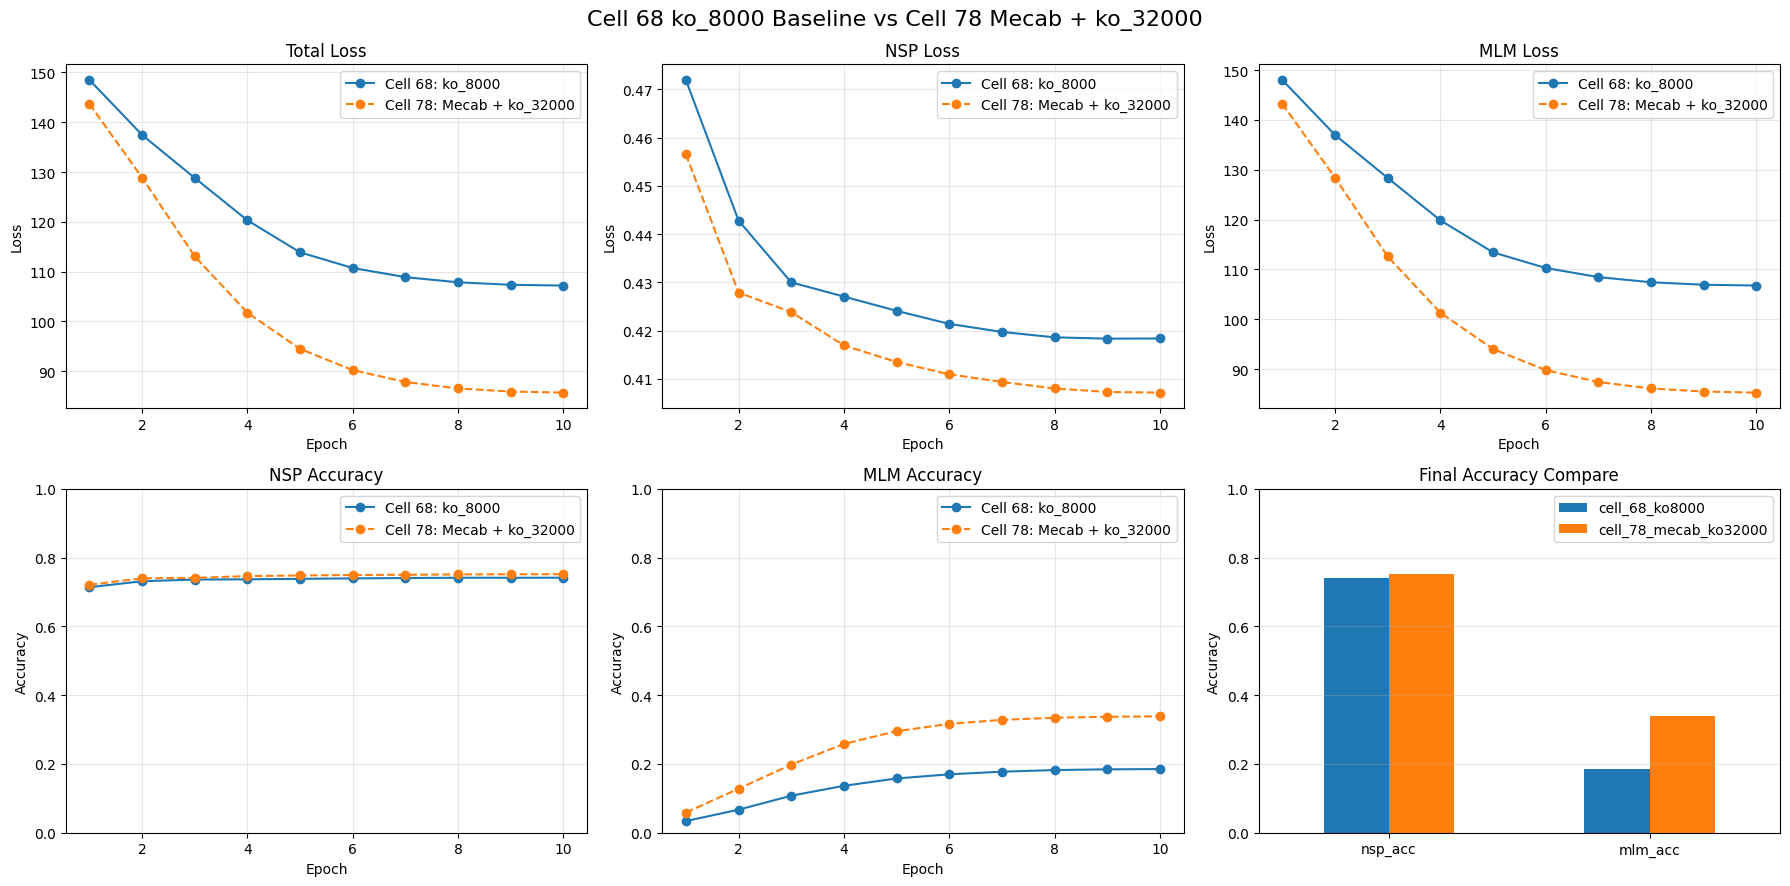

,cell_68_ko8000,cell_78_mecab_ko32000,delta_78_minus_68
total_loss,107.195802,85.703864,-21.491939
nsp_loss,0.418381,0.407174,-0.011207
mlm_loss,106.777421,85.296689,-21.480732
nsp_acc,0.741581,0.751732,0.010151
mlm_acc,0.185072,0.338258,0.153187


delta_78_minus_68: loss는 낮을수록 좋고, acc는 높을수록 좋습니다.


In [80]:
# 68번 셀(history_df) vs 78번 셀(history_mecab_df) 비교 시각화
import pandas as pd
import matplotlib.pyplot as plt

if "history_df" not in globals():
    if "history" in globals() and len(history.get("total_loss", [])) > 0:
        history_df = pd.DataFrame(history, index=range(1, len(history["total_loss"]) + 1))
        history_df.index.name = "epoch"
    else:
        raise RuntimeError("history_df가 없습니다. 68번 결과 시각화 셀을 먼저 실행해주세요.")

if "history_mecab_df" not in globals():
    if "history_mecab" in globals() and len(history_mecab.get("total_loss", [])) > 0:
        history_mecab_df = pd.DataFrame(history_mecab, index=range(1, len(history_mecab["total_loss"]) + 1))
        history_mecab_df.index.name = "epoch"
    else:
        raise RuntimeError("history_mecab_df가 없습니다. 78번 학습 셀을 먼저 실행해주세요.")

compare_cols = ["total_loss", "nsp_loss", "mlm_loss", "nsp_acc", "mlm_acc"]
for name, df in {"history_df": history_df, "history_mecab_df": history_mecab_df}.items():
    missing_cols = [col for col in compare_cols if col not in df.columns]
    if missing_cols:
        raise RuntimeError(f"{name}에 필요한 컬럼이 없습니다: {missing_cols}")
    if df.empty:
        raise RuntimeError(f"{name}가 비어 있습니다.")

baseline_df = history_df.copy()
mecab_df = history_mecab_df.copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
fig.suptitle("Cell 68 ko_8000 Baseline vs Cell 78 Mecab + ko_32000", fontsize=16)

plot_settings = [
    ("total_loss", "Total Loss", "Loss"),
    ("nsp_loss", "NSP Loss", "Loss"),
    ("mlm_loss", "MLM Loss", "Loss"),
    ("nsp_acc", "NSP Accuracy", "Accuracy"),
    ("mlm_acc", "MLM Accuracy", "Accuracy"),
]

for ax, (col, title, ylabel) in zip(axes, plot_settings):
    ax.plot(baseline_df.index, baseline_df[col], marker="o", label="Cell 68: ko_8000")
    ax.plot(mecab_df.index, mecab_df[col], marker="o", linestyle="--", label="Cell 78: Mecab + ko_32000")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    if "acc" in col:
        ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()

final_compare = pd.DataFrame({
    "cell_68_ko8000": baseline_df.iloc[-1][compare_cols],
    "cell_78_mecab_ko32000": mecab_df.iloc[-1][compare_cols],
})
final_compare["delta_78_minus_68"] = final_compare["cell_78_mecab_ko32000"] - final_compare["cell_68_ko8000"]

ax = axes[-1]
acc_compare = final_compare.loc[["nsp_acc", "mlm_acc"], ["cell_68_ko8000", "cell_78_mecab_ko32000"]]
acc_compare.plot(kind="bar", ax=ax, color=["tab:blue", "tab:orange"])
ax.set_title("Final Accuracy Compare")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

display(final_compare)
print("delta_78_minus_68: loss는 낮을수록 좋고, acc는 높을수록 좋습니다.")


## 실제 문장으로 MLM/NSP 테스트

metric 숫자 대신 직접 만든 문장에 `[MASK]`를 넣어 빈칸 예측을 확인하고, 두 문장의 순서가 자연스러운지도 확인합니다. 메모리에 기존 모델과 새 모델이 둘 다 남아 있거나 checkpoint가 있으면 비교하고, 하나만 가능하면 가능한 모델만 테스트합니다.


In [81]:
# 사용 가능한 pretrain 모델을 찾고, MLM/NSP 테스트용 helper를 정의합니다.
import re
from pathlib import Path
import pandas as pd
import torch
import torch.nn.functional as F
import sentencepiece as spm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _load_sentencepiece_from_path(model_path):
    model_path = Path(model_path)
    if not model_path.exists():
        return None
    processor = spm.SentencePieceProcessor()
    processor.load(str(model_path))
    return processor

def _latest_checkpoint(pattern):
    paths = list(Path("work").glob(pattern))
    if not paths:
        return None

    def epoch_number(path):
        match = re.search(r"epoch_(\d+)", path.stem)
        return int(match.group(1)) if match else -1

    return sorted(paths, key=lambda path: (epoch_number(path), path.stat().st_mtime))[-1]

def _copy_config_with_vocab(base_config, n_vocab, n_seq=128):
    if "Config" in globals():
        cfg = Config(dict(base_config))
    else:
        cfg = dict(base_config)
    cfg.n_vocab = int(n_vocab)
    cfg.n_seq = int(n_seq)
    cfg.i_pad = 0
    return cfg

def _load_model_from_checkpoint(checkpoint_path, cfg):
    if checkpoint_path is None or "build_model_pre_train" not in globals():
        return None
    model = build_model_pre_train(cfg)
    state = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state)
    return model

def _get_vocab(global_name, model_path):
    if global_name in globals():
        return globals()[global_name]
    return _load_sentencepiece_from_path(model_path)

def _register_candidate(candidates, name, model_var, vocab_obj, cfg_obj, checkpoint_pattern=None, is_mecab=False):
    if vocab_obj is None or cfg_obj is None:
        return

    source = None
    model = globals().get(model_var)
    cfg = _copy_config_with_vocab(cfg_obj, vocab_obj.get_piece_size())

    if model is not None:
        source = f"memory:{model_var}"
    else:
        checkpoint_path = _latest_checkpoint(checkpoint_pattern) if checkpoint_pattern else None
        try:
            model = _load_model_from_checkpoint(checkpoint_path, cfg)
            source = str(checkpoint_path) if model is not None else None
        except Exception as exc:
            print(f"{name} checkpoint load skipped: {exc}")
            model = None

    if model is None:
        return

    model.to(device)
    model.eval()
    candidates.append({
        "name": name,
        "model": model,
        "vocab": vocab_obj,
        "config": cfg,
        "source": source,
        "is_mecab": is_mecab,
    })

def _preprocess_text(text, is_mecab=False):
    if not is_mecab:
        return text
    tokenizer = globals().get("mecab_tokenizer")
    if tokenizer is None:
        return text
    pieces = []
    parts = text.split("[MASK]")
    for i, part in enumerate(parts):
        part = part.strip()
        if part:
            pieces.extend(tokenizer.morphs(part))
        if i < len(parts) - 1:
            pieces.append("[MASK]")
    return " ".join(pieces)

def _encode_with_mask(vocab_obj, text):
    tokens = []
    parts = text.split("[MASK]")
    for i, part in enumerate(parts):
        part = part.strip()
        if part:
            tokens.extend(vocab_obj.encode_as_pieces(part))
        if i < len(parts) - 1:
            tokens.append("[MASK]")
    return tokens

def _encode_sentence(vocab_obj, text, is_mecab=False):
    text = _preprocess_text(text, is_mecab=is_mecab)
    return vocab_obj.encode_as_pieces(text)

def _trim_pair(tokens_a, tokens_b, max_seq):
    tokens_a = list(tokens_a)
    tokens_b = list(tokens_b)
    while len(tokens_a) + len(tokens_b) > max_seq:
        if len(tokens_a) > len(tokens_b):
            tokens_a.pop(0)
        else:
            tokens_b.pop()
    return tokens_a, tokens_b

def predict_mask(candidate, sentence, top_k=5):
    model = candidate["model"]
    vocab_obj = candidate["vocab"]
    n_seq = int(candidate["config"].n_seq)
    text = _preprocess_text(sentence, is_mecab=candidate["is_mecab"])
    pieces = _encode_with_mask(vocab_obj, text)
    tokens = ["[CLS]"] + pieces[: n_seq - 2] + ["[SEP]"]
    mask_positions = [i for i, token in enumerate(tokens) if token == "[MASK]"]
    if not mask_positions:
        raise ValueError("문장에 [MASK]가 없거나 max sequence 길이 밖으로 잘렸습니다.")

    token_ids = [vocab_obj.piece_to_id(token) for token in tokens]
    segments = [0] * len(token_ids)
    pad_len = n_seq - len(token_ids)
    token_ids += [0] * pad_len
    segments += [0] * pad_len

    enc = torch.tensor([token_ids], dtype=torch.long, device=device)
    seg = torch.tensor([segments], dtype=torch.long, device=device)

    with torch.no_grad():
        _, logits_mlm = model(enc, seg)

    rows = []
    for mask_order, pos in enumerate(mask_positions, start=1):
        probs = F.softmax(logits_mlm[0, pos], dim=-1)
        values, indices = torch.topk(probs, k=top_k)
        for rank, (token_id, prob) in enumerate(zip(indices.tolist(), values.tolist()), start=1):
            rows.append({
                "model": candidate["name"],
                "mask_no": mask_order,
                "rank": rank,
                "piece": vocab_obj.id_to_piece(token_id),
                "prob": prob,
            })
    return pd.DataFrame(rows)

def predict_nsp(candidate, sentence_a, sentence_b):
    model = candidate["model"]
    vocab_obj = candidate["vocab"]
    n_seq = int(candidate["config"].n_seq)
    tokens_a = _encode_sentence(vocab_obj, sentence_a, is_mecab=candidate["is_mecab"])
    tokens_b = _encode_sentence(vocab_obj, sentence_b, is_mecab=candidate["is_mecab"])
    tokens_a, tokens_b = _trim_pair(tokens_a, tokens_b, n_seq - 3)

    tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
    segments = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
    token_ids = [vocab_obj.piece_to_id(token) for token in tokens]
    pad_len = n_seq - len(token_ids)
    token_ids += [0] * pad_len
    segments += [0] * pad_len

    enc = torch.tensor([token_ids], dtype=torch.long, device=device)
    seg = torch.tensor([segments], dtype=torch.long, device=device)

    with torch.no_grad():
        logits_nsp, _ = model(enc, seg)
        probs = F.softmax(logits_nsp[0], dim=-1)

    return {
        "model": candidate["name"],
        "prob_not_next": probs[0].item(),
        "prob_is_next": probs[1].item(),
        "prediction": "is_next" if probs[1] >= probs[0] else "not_next",
    }

available_pretrain_models = []
baseline_vocab = _get_vocab("vocab", Path("data") / "ko_8000.model")
mecab_vocab_for_test = _get_vocab("vocab_mecab", Path("data") / "ko_32000.model")

if "config" in globals():
    _register_candidate(
        available_pretrain_models,
        name="cell68_ko8000",
        model_var="pre_train_model",
        vocab_obj=baseline_vocab,
        cfg_obj=config,
        checkpoint_pattern="mini_bert_pre_train_epoch_*.pt",
        is_mecab=False,
    )

if "config_mecab" in globals() or "config" in globals():
    _register_candidate(
        available_pretrain_models,
        name="cell78_mecab_ko32000",
        model_var="pre_train_model_mecab",
        vocab_obj=mecab_vocab_for_test,
        cfg_obj=globals().get("config_mecab", globals().get("config")),
        checkpoint_pattern="mini_bert_mecab_ko_32000_epoch_*.pt",
        is_mecab=True,
    )

if not available_pretrain_models:
    raise RuntimeError("사용 가능한 모델이 없습니다. 학습 셀을 실행했거나 checkpoint가 있는지 확인해주세요.")

print("사용 가능한 모델")
for candidate in available_pretrain_models:
    print(f"- {candidate['name']} | vocab={candidate['vocab'].get_piece_size()} | source={candidate['source']}")

if len(available_pretrain_models) == 1:
    print("비교 가능한 다른 모델이 없어서 사용 가능한 최신 모델 하나로만 테스트합니다.")


사용 가능한 모델
- cell68_ko8000 | vocab=8000 | source=memory:pre_train_model
- cell78_mecab_ko32000 | vocab=32000 | source=memory:pre_train_model_mecab


In [82]:
# 실제 문장으로 빈칸 채우기(MLM)와 문장 순서(NSP)를 테스트합니다.
mask_test_sentences = [
    "인공지능은 컴퓨터가 사람처럼 [MASK]하고 추론하도록 만드는 기술이다.",
    "자연어 처리는 사람이 사용하는 [MASK]를 컴퓨터가 이해하도록 만드는 분야이다.",
    "BERT는 Transformer [MASK] 구조를 기반으로 만들어진 언어 모델이다.",
]

nsp_test_pairs = [
    {
        "case": "natural_pair",
        "sentence_a": "인공지능은 컴퓨터가 사람처럼 학습하고 추론하도록 만드는 기술이다.",
        "sentence_b": "자연어 처리는 사람이 사용하는 언어를 컴퓨터가 이해하도록 만드는 분야이다.",
    },
    {
        "case": "swapped_or_weak_pair",
        "sentence_a": "BERT는 Transformer encoder 구조를 기반으로 만들어진 언어 모델이다.",
        "sentence_b": "손바닥 위엔 기쁨의 눈물이 흘러 목에 모주 한잔을 적셨다.",
    },
]

all_mlm_results = []
for sentence in mask_test_sentences:
    print("\n[MASK TEST]", sentence)
    sentence_results = []
    for candidate in available_pretrain_models:
        result_df = predict_mask(candidate, sentence, top_k=5)
        result_df.insert(0, "sentence", sentence)
        sentence_results.append(result_df)
        all_mlm_results.append(result_df)
    display(pd.concat(sentence_results, ignore_index=True))

all_nsp_results = []
for pair in nsp_test_pairs:
    print("\n[NSP TEST]", pair["case"])
    print("A:", pair["sentence_a"])
    print("B:", pair["sentence_b"])
    pair_rows = []
    for candidate in available_pretrain_models:
        row = predict_nsp(candidate, pair["sentence_a"], pair["sentence_b"])
        row["case"] = pair["case"]
        row["sentence_a"] = pair["sentence_a"]
        row["sentence_b"] = pair["sentence_b"]
        pair_rows.append(row)
        all_nsp_results.append(row)
    display(pd.DataFrame(pair_rows)[["case", "model", "prob_not_next", "prob_is_next", "prediction"]])

mlm_test_df = pd.concat(all_mlm_results, ignore_index=True) if all_mlm_results else pd.DataFrame()
nsp_test_df = pd.DataFrame(all_nsp_results)

print("\n테스트 결과는 mlm_test_df, nsp_test_df 변수에 저장되었습니다.")
print("주의: 이 모델은 mini pretraining 실험용이라 실제 정답 문장 판단 능력은 제한적입니다. 모델 간 경향 비교용으로 보는 게 좋습니다.")



[MASK TEST] 인공지능은 컴퓨터가 사람처럼 [MASK]하고 추론하도록 만드는 기술이다.


,sentence,model,mask_no,rank,piece,prob
0,인공지능은 컴퓨터가 사람처럼 [MASK]하고 추론하도록 만드는 기술이다.,cell68_ko8000,1,1,▁역할을,0.115712
1,인공지능은 컴퓨터가 사람처럼 [MASK]하고 추론하도록 만드는 기술이다.,cell68_ko8000,1,2,▁것을,0.068233
2,인공지능은 컴퓨터가 사람처럼 [MASK]하고 추론하도록 만드는 기술이다.,cell68_ko8000,1,3,▁것으로,0.042863
3,인공지능은 컴퓨터가 사람처럼 [MASK]하고 추론하도록 만드는 기술이다.,cell68_ko8000,1,4,을,0.037874
4,인공지능은 컴퓨터가 사람처럼 [MASK]하고 추론하도록 만드는 기술이다.,cell68_ko8000,1,5,▁잘,0.036824
5,인공지능은 컴퓨터가 사람처럼 [MASK]하고 추론하도록 만드는 기술이다.,cell78_mecab_ko32000,1,1,▁사용,0.067376
6,인공지능은 컴퓨터가 사람처럼 [MASK]하고 추론하도록 만드는 기술이다.,cell78_mecab_ko32000,1,2,▁제공,0.060855
7,인공지능은 컴퓨터가 사람처럼 [MASK]하고 추론하도록 만드는 기술이다.,cell78_mecab_ko32000,1,3,▁설명,0.048251
8,인공지능은 컴퓨터가 사람처럼 [MASK]하고 추론하도록 만드는 기술이다.,cell78_mecab_ko32000,1,4,▁말,0.024205
9,인공지능은 컴퓨터가 사람처럼 [MASK]하고 추론하도록 만드는 기술이다.,cell78_mecab_ko32000,1,5,▁정의,0.022344



[MASK TEST] 자연어 처리는 사람이 사용하는 [MASK]를 컴퓨터가 이해하도록 만드는 분야이다.


,sentence,model,mask_no,rank,piece,prob
0,자연어 처리는 사람이 사용하는 [MASK]를 컴퓨터가 이해하도록 만드는 분야이다.,cell68_ko8000,1,1,▁다른,0.027695
1,자연어 처리는 사람이 사용하는 [MASK]를 컴퓨터가 이해하도록 만드는 분야이다.,cell68_ko8000,1,2,▁언어,0.025760
2,자연어 처리는 사람이 사용하는 [MASK]를 컴퓨터가 이해하도록 만드는 분야이다.,cell68_ko8000,1,3,▁같은,0.021327
3,자연어 처리는 사람이 사용하는 [MASK]를 컴퓨터가 이해하도록 만드는 분야이다.,cell68_ko8000,1,4,▁다양한,0.016354
4,자연어 처리는 사람이 사용하는 [MASK]를 컴퓨터가 이해하도록 만드는 분야이다.,cell68_ko8000,1,5,▁여러,0.013721
5,자연어 처리는 사람이 사용하는 [MASK]를 컴퓨터가 이해하도록 만드는 분야이다.,cell78_mecab_ko32000,1,1,▁언어,0.087923
6,자연어 처리는 사람이 사용하는 [MASK]를 컴퓨터가 이해하도록 만드는 분야이다.,cell78_mecab_ko32000,1,2,▁정보,0.061285
7,자연어 처리는 사람이 사용하는 [MASK]를 컴퓨터가 이해하도록 만드는 분야이다.,cell78_mecab_ko32000,1,3,▁용어,0.058395
8,자연어 처리는 사람이 사용하는 [MASK]를 컴퓨터가 이해하도록 만드는 분야이다.,cell78_mecab_ko32000,1,4,▁의미,0.038423
9,자연어 처리는 사람이 사용하는 [MASK]를 컴퓨터가 이해하도록 만드는 분야이다.,cell78_mecab_ko32000,1,5,▁분야,0.035919



[MASK TEST] BERT는 Transformer [MASK] 구조를 기반으로 만들어진 언어 모델이다.


...


[NSP TEST] natural_pair
A: 인공지능은 컴퓨터가 사람처럼 학습하고 추론하도록 만드는 기술이다.
B: 자연어 처리는 사람이 사용하는 언어를 컴퓨터가 이해하도록 만드는 분야이다.


,case,model,prob_not_next,prob_is_next,prediction
0,natural_pair,cell68_ko8000,0.447875,0.552125,is_next
1,natural_pair,cell78_mecab_ko32000,0.553755,0.446245,not_next



[NSP TEST] swapped_or_weak_pair
A: BERT는 Transformer encoder 구조를 기반으로 만들어진 언어 모델이다.
B: 손바닥 위엔 기쁨의 눈물이 흘러 목에 모주 한잔을 적셨다.


,case,model,prob_not_next,prob_is_next,prediction
0,swapped_or_weak_pair,cell68_ko8000,0.391719,0.608281,is_next
1,swapped_or_weak_pair,cell78_mecab_ko32000,0.361609,0.638391,is_next



테스트 결과는 mlm_test_df, nsp_test_df 변수에 저장되었습니다.
주의: 이 모델은 mini pretraining 실험용이라 실제 정답 문장 판단 능력은 제한적입니다. 모델 간 경향 비교용으로 보는 게 좋습니다.


## 사용 가능한 모델 2개 저장

현재 커널 메모리에 있는 기존 모델과 Mecab 모델을 `work/saved_pretrain_models` 아래에 저장합니다. 메모리에 없으면 기존 학습 셀에서 저장한 최신 checkpoint를 찾아 같은 export 포맷으로 저장합니다.


In [83]:
# 현재 사용 가능한 두 모델을 재사용 가능한 export 파일로 저장합니다.
import json
import re
import time
from pathlib import Path

import pandas as pd
import sentencepiece as spm
import torch

export_dir = Path("work") / "saved_pretrain_models"
export_dir.mkdir(parents=True, exist_ok=True)

def latest_checkpoint(pattern):
    paths = list(Path("work").glob(pattern))
    if not paths:
        return None

    def epoch_number(path):
        match = re.search(r"epoch_(\d+)", path.stem)
        return int(match.group(1)) if match else -1

    return sorted(paths, key=lambda path: (epoch_number(path), path.stat().st_mtime))[-1]

def vocab_size_from_sentencepiece(model_path):
    processor = spm.SentencePieceProcessor()
    processor.load(str(model_path))
    return processor.get_piece_size()

def state_dict_from_model_or_checkpoint(model_var_name, checkpoint_pattern):
    model = globals().get(model_var_name)
    if model is not None:
        state_dict = {key: value.detach().cpu() for key, value in model.state_dict().items()}
        return state_dict, f"memory:{model_var_name}"

    checkpoint_path = latest_checkpoint(checkpoint_pattern)
    if checkpoint_path is None:
        return None, None
    state_dict = torch.load(checkpoint_path, map_location="cpu")
    return state_dict, str(checkpoint_path)

def infer_n_vocab_from_state_dict(state_dict, fallback_n_vocab, d_model):
    row_candidates = []
    for key, value in state_dict.items():
        if not torch.is_tensor(value):
            continue
        if value.ndim == 2 and value.shape[1] == d_model and value.shape[0] > 1000:
            row_candidates.append(int(value.shape[0]))
        elif value.ndim == 1 and value.shape[0] > 1000 and any(word in key.lower() for word in ("bias", "vocab", "decoder", "projection")):
            row_candidates.append(int(value.shape[0]))
    return max(row_candidates) if row_candidates else int(fallback_n_vocab)

def plain_config_for_export(base_config, n_vocab):
    cfg = dict(base_config)
    cfg["n_vocab"] = int(n_vocab)
    cfg["n_seq"] = int(cfg.get("n_seq", 128))
    cfg["i_pad"] = int(cfg.get("i_pad", 0))
    return cfg

def export_pretrain_model(export_name, model_var_name, base_config, vocab_model_path, checkpoint_pattern, is_mecab):
    vocab_model_path = Path(vocab_model_path)
    if not vocab_model_path.exists():
        raise FileNotFoundError(f"SentencePiece model file not found: {vocab_model_path}")

    state_dict, source = state_dict_from_model_or_checkpoint(model_var_name, checkpoint_pattern)
    if state_dict is None:
        raise RuntimeError(f"{export_name} 모델을 찾지 못했습니다. 메모리 변수나 checkpoint를 확인하세요.")

    d_model = int(dict(base_config).get("d_model", 80))
    fallback_n_vocab = vocab_size_from_sentencepiece(vocab_model_path)
    n_vocab = infer_n_vocab_from_state_dict(state_dict, fallback_n_vocab, d_model)
    cfg = plain_config_for_export(base_config, n_vocab)

    export_path = export_dir / f"{export_name}.pt"
    payload = {
        "model_name": export_name,
        "source": source,
        "saved_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "config": cfg,
        "vocab_model_path": str(vocab_model_path),
        "is_mecab": bool(is_mecab),
        "state_dict": state_dict,
    }
    torch.save(payload, export_path)

    return {
        "model_name": export_name,
        "export_path": str(export_path),
        "source": source,
        "n_vocab": n_vocab,
        "is_mecab": bool(is_mecab),
    }

if "config" not in globals():
    raise RuntimeError("config가 없습니다. 모델 정의 셀까지 먼저 실행해주세요.")

baseline_vocab_path = Path("data") / "ko_8000.model"
mecab_vocab_path = Path("data") / "ko_32000.model"
mecab_export_config = globals().get("config_mecab", config)

export_rows = []
export_rows.append(export_pretrain_model(
    export_name="cell68_ko8000_pretrain",
    model_var_name="pre_train_model",
    base_config=config,
    vocab_model_path=baseline_vocab_path,
    checkpoint_pattern="mini_bert_pre_train_epoch_*.pt",
    is_mecab=False,
))
export_rows.append(export_pretrain_model(
    export_name="cell78_mecab_ko32000_pretrain",
    model_var_name="pre_train_model_mecab",
    base_config=mecab_export_config,
    vocab_model_path=mecab_vocab_path,
    checkpoint_pattern="mini_bert_mecab_ko_32000_epoch_*.pt",
    is_mecab=True,
))

exported_model_files = [row["export_path"] for row in export_rows]
export_summary_df = pd.DataFrame(export_rows)
display(export_summary_df)
print("exported_model_files:")
for path in exported_model_files:
    print("-", path)


,model_name,export_path,source,n_vocab,is_mecab
0,cell68_ko8000_pretrain,work\saved_pretrain_models\cell68_ko8000_pretr...,memory:pre_train_model,8000,False
1,cell78_mecab_ko32000_pretrain,work\saved_pretrain_models\cell78_mecab_ko3200...,memory:pre_train_model_mecab,32000,True


exported_model_files:
- work\saved_pretrain_models\cell68_ko8000_pretrain.pt
- work\saved_pretrain_models\cell78_mecab_ko32000_pretrain.pt


## 저장한 모델 불러오기 + 일상 문장 비교 테스트

위 셀에서 저장한 두 export 파일을 다시 불러온 뒤, 일상 문장 예시 5개로 MLM 빈칸 채우기와 NSP 문장 순서 판단을 비교합니다.


In [84]:
# 저장된 두 모델을 다시 불러와 MLM 5개, NSP 5개 일상 문장 예시로 비교합니다.
from pathlib import Path
import pandas as pd
import sentencepiece as spm
import torch
import torch.nn.functional as F

if "build_model_pre_train" not in globals():
    raise RuntimeError("build_model_pre_train()이 없습니다. 모델 클래스/빌드 함수 정의 셀을 먼저 실행해주세요.")

class AttrConfig(dict):
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

def config_from_payload(config_dict):
    if "Config" in globals():
        return Config(config_dict)
    return AttrConfig(config_dict)

def get_mecab_tokenizer_if_possible():
    if "mecab_tokenizer" in globals():
        return mecab_tokenizer
    try:
        import mecab as mecab_module
        return mecab_module.MeCab()
    except Exception:
        try:
            from konlpy.tag import Mecab
            return Mecab()
        except Exception:
            return None

def load_exported_pretrain_model(export_path, device):
    package = torch.load(export_path, map_location=device)
    cfg = config_from_payload(package["config"])
    model = build_model_pre_train(cfg)
    model.load_state_dict(package["state_dict"])
    model.to(device)
    model.eval()

    vocab_processor = spm.SentencePieceProcessor()
    vocab_processor.load(package["vocab_model_path"])

    return {
        "name": package["model_name"],
        "model": model,
        "config": cfg,
        "vocab": vocab_processor,
        "is_mecab": bool(package.get("is_mecab", False)),
        "source": package.get("source", "unknown"),
        "path": str(export_path),
    }

def preprocess_for_model(text, is_mecab, tokenizer):
    if not is_mecab or tokenizer is None:
        return text
    pieces = []
    parts = text.split("[MASK]")
    for i, part in enumerate(parts):
        part = part.strip()
        if part:
            pieces.extend(tokenizer.morphs(part))
        if i < len(parts) - 1:
            pieces.append("[MASK]")
    return " ".join(pieces)

def encode_with_mask(vocab_processor, text):
    tokens = []
    parts = text.split("[MASK]")
    for i, part in enumerate(parts):
        part = part.strip()
        if part:
            tokens.extend(vocab_processor.encode_as_pieces(part))
        if i < len(parts) - 1:
            tokens.append("[MASK]")
    return tokens

def trim_pair(tokens_a, tokens_b, max_seq):
    tokens_a = list(tokens_a)
    tokens_b = list(tokens_b)
    while len(tokens_a) + len(tokens_b) > max_seq:
        if len(tokens_a) > len(tokens_b):
            tokens_a.pop(0)
        else:
            tokens_b.pop()
    return tokens_a, tokens_b

def predict_mlm_for_sentence(candidate, sentence, tokenizer, top_k=5):
    model = candidate["model"]
    vocab_processor = candidate["vocab"]
    n_seq = int(candidate["config"].n_seq)
    processed = preprocess_for_model(sentence, candidate["is_mecab"], tokenizer)
    pieces = encode_with_mask(vocab_processor, processed)
    tokens = ["[CLS]"] + pieces[: n_seq - 2] + ["[SEP]"]
    mask_positions = [i for i, token in enumerate(tokens) if token == "[MASK]"]
    if not mask_positions:
        return pd.DataFrame([{"model": candidate["name"], "sentence": sentence, "error": "[MASK]가 없거나 잘렸습니다."}])

    token_ids = [vocab_processor.piece_to_id(token) for token in tokens]
    segments = [0] * len(token_ids)
    pad_len = n_seq - len(token_ids)
    token_ids += [0] * pad_len
    segments += [0] * pad_len

    enc = torch.tensor([token_ids], dtype=torch.long, device=device)
    seg = torch.tensor([segments], dtype=torch.long, device=device)
    with torch.no_grad():
        _, logits_mlm = model(enc, seg)

    rows = []
    for mask_no, pos in enumerate(mask_positions, start=1):
        probs = F.softmax(logits_mlm[0, pos], dim=-1)
        values, indices = torch.topk(probs, k=top_k)
        for rank, (token_id, prob) in enumerate(zip(indices.tolist(), values.tolist()), start=1):
            rows.append({
                "sentence": sentence,
                "model": candidate["name"],
                "mask_no": mask_no,
                "rank": rank,
                "piece": vocab_processor.id_to_piece(token_id),
                "prob": prob,
            })
    return pd.DataFrame(rows)

def predict_nsp_for_pair(candidate, sentence_a, sentence_b, tokenizer):
    model = candidate["model"]
    vocab_processor = candidate["vocab"]
    n_seq = int(candidate["config"].n_seq)
    text_a = preprocess_for_model(sentence_a, candidate["is_mecab"], tokenizer)
    text_b = preprocess_for_model(sentence_b, candidate["is_mecab"], tokenizer)
    tokens_a = vocab_processor.encode_as_pieces(text_a)
    tokens_b = vocab_processor.encode_as_pieces(text_b)
    tokens_a, tokens_b = trim_pair(tokens_a, tokens_b, n_seq - 3)

    tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
    segments = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
    token_ids = [vocab_processor.piece_to_id(token) for token in tokens]
    pad_len = n_seq - len(token_ids)
    token_ids += [0] * pad_len
    segments += [0] * pad_len

    enc = torch.tensor([token_ids], dtype=torch.long, device=device)
    seg = torch.tensor([segments], dtype=torch.long, device=device)
    with torch.no_grad():
        logits_nsp, _ = model(enc, seg)
        probs = F.softmax(logits_nsp[0], dim=-1)

    return {
        "model": candidate["name"],
        "prob_not_next": probs[0].item(),
        "prob_is_next": probs[1].item(),
        "prediction": "is_next" if probs[1] >= probs[0] else "not_next",
    }

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
default_export_paths = [
    Path("work") / "saved_pretrain_models" / "cell68_ko8000_pretrain.pt",
    Path("work") / "saved_pretrain_models" / "cell78_mecab_ko32000_pretrain.pt",
]
model_paths_to_load = [Path(path) for path in globals().get("exported_model_files", default_export_paths)]
model_paths_to_load = [path for path in model_paths_to_load if path.exists()]
if len(model_paths_to_load) < 2:
    raise RuntimeError("저장된 모델 파일 2개를 찾지 못했습니다. 바로 위 저장 셀을 먼저 실행해주세요.")

mecab_tokenizer_for_test = get_mecab_tokenizer_if_possible()
loaded_export_models = [load_exported_pretrain_model(path, device) for path in model_paths_to_load[:2]]

print("Loaded exported models")
for candidate in loaded_export_models:
    print(f"- {candidate['name']} | vocab={candidate['vocab'].get_piece_size()} | is_mecab={candidate['is_mecab']} | path={candidate['path']}")

mlm_examples = [
    "오늘 아침에 따뜻한 [MASK] 한 잔을 마셨다.",
    "비가 와서 우산을 [MASK] 집을 나섰다.",
    "저녁에는 가족과 함께 [MASK]를 먹었다.",
    "버스가 늦게 와서 약속 시간에 [MASK].",
    "주말에는 친구와 공원에서 [MASK]을 했다.",
]

nsp_examples = [
    {"case": "daily_1", "sentence_a": "아침에 눈을 뜨자마자 창문을 열었다.", "sentence_b": "시원한 바람이 방 안으로 들어왔다."},
    {"case": "daily_2", "sentence_a": "냉장고를 열어 보니 우유가 없었다.", "sentence_b": "그래서 편의점에 가서 우유를 샀다."},
    {"case": "daily_3", "sentence_a": "퇴근 후 운동화를 신고 집을 나섰다.", "sentence_b": "동네 한 바퀴를 천천히 걸었다."},
    {"case": "daily_4", "sentence_a": "지하철에 사람이 많아서 서서 갔다.", "sentence_b": "회사에 도착하니 다리가 조금 피곤했다."},
    {"case": "daily_5", "sentence_a": "저녁 식사를 준비하려고 쌀을 씻었다.", "sentence_b": "밥솥에 물을 맞추고 취사 버튼을 눌렀다."},
]

all_mlm_export_results = []
for sentence in mlm_examples:
    rows = []
    for candidate in loaded_export_models:
        result = predict_mlm_for_sentence(candidate, sentence, mecab_tokenizer_for_test, top_k=5)
        rows.append(result)
        all_mlm_export_results.append(result)
    print("\n[MLM]", sentence)
    display(pd.concat(rows, ignore_index=True))

all_nsp_export_results = []
for example in nsp_examples:
    rows = []
    for candidate in loaded_export_models:
        row = predict_nsp_for_pair(candidate, example["sentence_a"], example["sentence_b"], mecab_tokenizer_for_test)
        row["case"] = example["case"]
        row["sentence_a"] = example["sentence_a"]
        row["sentence_b"] = example["sentence_b"]
        rows.append(row)
        all_nsp_export_results.append(row)
    print("\n[NSP]", example["case"])
    print("A:", example["sentence_a"])
    print("B:", example["sentence_b"])
    display(pd.DataFrame(rows)[["case", "model", "prob_not_next", "prob_is_next", "prediction"]])

mlm_export_test_df = pd.concat(all_mlm_export_results, ignore_index=True)
nsp_export_test_df = pd.DataFrame(all_nsp_export_results)

print("\n결과 변수: mlm_export_test_df, nsp_export_test_df")
print("주의: NSP는 이 노트북에서 문장 순서 뒤집기 방식으로 단순 구성된 실험 태스크라 실제 문맥 판단과 완전히 같지는 않습니다.")


Loaded exported models
- cell68_ko8000_pretrain | vocab=8000 | is_mecab=False | path=work\saved_pretrain_models\cell68_ko8000_pretrain.pt
- cell78_mecab_ko32000_pretrain | vocab=32000 | is_mecab=True | path=work\saved_pretrain_models\cell78_mecab_ko32000_pretrain.pt

[MLM] 오늘 아침에 따뜻한 [MASK] 한 잔을 마셨다.


,sentence,model,mask_no,rank,piece,prob
0,오늘 아침에 따뜻한 [MASK] 한 잔을 마셨다.,cell68_ko8000_pretrain,1,1,▁이름을,0.074249
1,오늘 아침에 따뜻한 [MASK] 한 잔을 마셨다.,cell68_ko8000_pretrain,1,2,▁사람은,0.068848
2,오늘 아침에 따뜻한 [MASK] 한 잔을 마셨다.,cell68_ko8000_pretrain,1,3,▁사람이,0.038855
3,오늘 아침에 따뜻한 [MASK] 한 잔을 마셨다.,cell68_ko8000_pretrain,1,4,▁말을,0.031982
4,오늘 아침에 따뜻한 [MASK] 한 잔을 마셨다.,cell68_ko8000_pretrain,1,5,▁것을,0.030643
5,오늘 아침에 따뜻한 [MASK] 한 잔을 마셨다.,cell78_mecab_ko32000_pretrain,1,1,▁유일,0.093376
6,오늘 아침에 따뜻한 [MASK] 한 잔을 마셨다.,cell78_mecab_ko32000_pretrain,1,2,▁듯,0.064345
7,오늘 아침에 따뜻한 [MASK] 한 잔을 마셨다.,cell78_mecab_ko32000_pretrain,1,3,▁다양,0.045987
8,오늘 아침에 따뜻한 [MASK] 한 잔을 마셨다.,cell78_mecab_ko32000_pretrain,1,4,▁유명,0.037390
9,오늘 아침에 따뜻한 [MASK] 한 잔을 마셨다.,cell78_mecab_ko32000_pretrain,1,5,▁독특,0.032375



[MLM] 비가 와서 우산을 [MASK] 집을 나섰다.


,sentence,model,mask_no,rank,piece,prob
0,비가 와서 우산을 [MASK] 집을 나섰다.,cell68_ko8000_pretrain,1,1,▁대한,0.092625
1,비가 와서 우산을 [MASK] 집을 나섰다.,cell68_ko8000_pretrain,1,2,▁가진,0.082605
2,비가 와서 우산을 [MASK] 집을 나섰다.,cell68_ko8000_pretrain,1,3,▁있는,0.073139
3,비가 와서 우산을 [MASK] 집을 나섰다.,cell68_ko8000_pretrain,1,4,▁같은,0.027130
4,비가 와서 우산을 [MASK] 집을 나섰다.,cell68_ko8000_pretrain,1,5,▁대해,0.020594
5,비가 와서 우산을 [MASK] 집을 나섰다.,cell78_mecab_ko32000_pretrain,1,1,▁한,0.102079
6,비가 와서 우산을 [MASK] 집을 나섰다.,cell78_mecab_ko32000_pretrain,1,2,▁두,0.070696
7,비가 와서 우산을 [MASK] 집을 나섰다.,cell78_mecab_ko32000_pretrain,1,3,▁통해,0.040687
8,비가 와서 우산을 [MASK] 집을 나섰다.,cell78_mecab_ko32000_pretrain,1,4,▁3,0.026354
9,비가 와서 우산을 [MASK] 집을 나섰다.,cell78_mecab_ko32000_pretrain,1,5,▁첫,0.023794



[MLM] 저녁에는 가족과 함께 [MASK]를 먹었다.


...


[NSP] daily_4
A: 지하철에 사람이 많아서 서서 갔다.
B: 회사에 도착하니 다리가 조금 피곤했다.


,case,model,prob_not_next,prob_is_next,prediction
0,daily_4,cell68_ko8000_pretrain,0.589782,0.410218,not_next
1,daily_4,cell78_mecab_ko32000_pretrain,0.499649,0.500351,is_next



[NSP] daily_5
A: 저녁 식사를 준비하려고 쌀을 씻었다.
B: 밥솥에 물을 맞추고 취사 버튼을 눌렀다.


,case,model,prob_not_next,prob_is_next,prediction
0,daily_5,cell68_ko8000_pretrain,0.504504,0.495496,not_next
1,daily_5,cell78_mecab_ko32000_pretrain,0.485861,0.514139,is_next



결과 변수: mlm_export_test_df, nsp_export_test_df
주의: NSP는 이 노트북에서 문장 순서 뒤집기 방식으로 단순 구성된 실험 태스크라 실제 문맥 판단과 완전히 같지는 않습니다.


## 회고

### A 모델 학습 결과 (68번 셀)
- 전반적으로 epoch가 진행되면서 loss가 감소하고 acc는 증가함을 보여주었다.
#### Next Sentence Prediction (NSP)
- nsp_loss는 크게 줄어들지는 않았지만 0.47->0.42로 약 15% 감소하였다.
- nsp_acc는 71%에서 74%로 증가하였는데 7 epoch이후로는 큰변화가 없었다.
#### Masked Language Modeling (MLM)
- mlm_loss, mlm_acc 정확도가 3.4%에서 18.5%까지 증가하긴했으나 너무 낮은 정확도로 보이며 증가추세가 크게 감소한걸로 보아 문제가 있는것으로 보인다.


## 성능이 불만족스러워서 Vocab_size 다시 32000으로 늘리고 Mecab으로 말뭉치 생성후 SentencePiece로 다시 학습.

### B 모델 학습 결과 (78번 셀)
아래 비교 시각화 자료 참조. MLM은 꽤많이 올랐음.

### 배운점
- 모름.
- 솔직히 잘모르겠음. NSP 정확도가 75%정도되는데 A모델같은경우는 5개다 틀리고 B모델은 좀더높은데 3개는 맞췄지만 50~51%로 맞춘거라 이걸 맞췄다고 하기도 애매함.
- MLM은 두 모델 전부 5개 예문 다 틀림. 
- 뭔가 데이터 질적으로 양적으로 좋고 잘학습시킬수록 성능이 늘어날 가능성이 높아진다는건 알겠는데 뭔가 손에 만져지지 않는것같아서 계속 지쳐감..

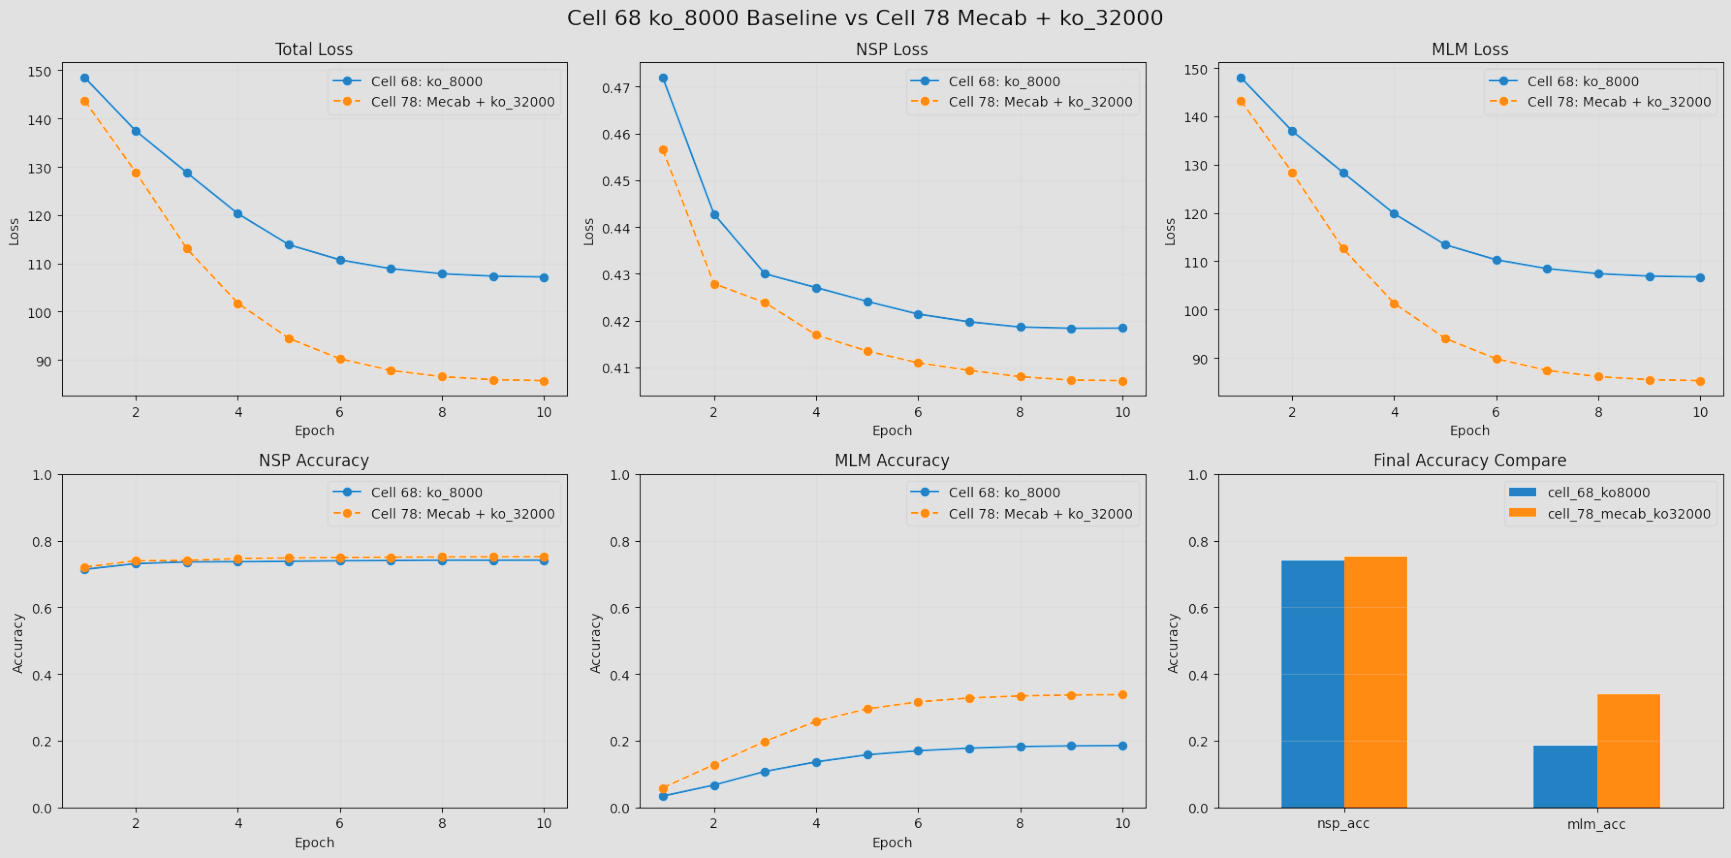